# Saved-run evaluation (`best.pt`)
Run from the repository root or `main_notebooks/`. This notebook never retrains or overwrites the selected run. `EVALUATION_DATA_ROOT` can evaluate a checkpoint against a different prepared train/validation split; that override is used consistently for window metrics, continuous metrics, and exported comparison fingerprints. Validation is used for model selection; it is not an independent test set.

**Primary measure:** one alarm per physical double tap on a continuous recording. A correct-side alarm emitted **up to 20 frames before** the labeled second tap is accepted to accommodate auto-labeler timing errors. Late matches are allowed up to 30 frames: the inclusive matching interval is **−20 to +30 frames** (−200 to +300 ms at 100 Hz). Matching is one-to-one; extra or wrong-side alarms still count as errors. Timing is measured at *emission*, not at the probability peak.

Full-recording `forward()` is causal in eval mode and is checked against chunked and single-frame `model.step()` inference. Postprocessing consumes only probabilities available at each emission frame. This assesses the learned model and its streaming implementation under the evaluated policy.

In [30]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.optimize import linear_sum_assignment
from scipy.stats import rankdata
from torch.utils.data import DataLoader

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Open from repository root or main_notebooks/'
sys.path.insert(0, str(ROOT))

from tap_recognition.config import TrainConfig
from tap_recognition.model_factory import build_model
from train import build_datasets, frame_soft_ce, window_class_from_probs
from notebooks_analysis.state_reset_analysis import load_recordings, overlap_stream_logits

# Change this when evaluating a different run.
RUN_DIR = ROOT / 'testing_checkpoints/lstm64d10(102)'

# None evaluates on the checkpoint's recorded split. Set this to a prepared
# dataset root containing train_data/, valid_data/, and session_exclusions.csv
# to compare checkpoints on the same expanded split.
EVALUATION_DATA_ROOT = ROOT / 'data_05_10_26'
# Fix window-negative sampling across checkpoints. This does not change a checkpoint's training seed.
EVALUATION_SEED = 101

# None selects a safe default. With an evaluation-data override, exports go to
# testing_checkpoints/evaluation_exports/ instead of overwriting the checkpoint's
# historical threshold_comparison/ directory.
EVALUATION_OUTPUT_DIR = None

checkpoint = torch.load(RUN_DIR / 'best.pt', map_location='cpu', weights_only=True)
saved = checkpoint['train_config']
cfg = TrainConfig()
for key, value in saved['data'].items():
    setattr(cfg.data, key, value)
for key, value in saved['labels'].items():
    setattr(cfg.labels, key, value)
for key, value in saved['training'].items():
    if key == 'early_stopping':
        for name, setting in value.items():
            setattr(cfg.training.early_stopping, name, setting)
    else:
        setattr(cfg.training, key, value)
checkpoint_training_seed = saved['seed']
cfg.seed = checkpoint_training_seed

if EVALUATION_DATA_ROOT is None:
    evaluation_data_root = None
    for key in ('train_dir', 'val_dir'):
        directories = getattr(cfg.data, key).split(',')
        setattr(cfg.data, key, ','.join(str((ROOT / directory.strip()).resolve()) for directory in directories))
    registry = Path(cfg.data.session_exclusions_file)
    cfg.data.session_exclusions_file = str((ROOT / registry).resolve()) if not registry.is_absolute() else str(registry)
else:
    evaluation_data_root = Path(EVALUATION_DATA_ROOT).resolve()
    for name in ('train_data', 'valid_data'):
        directory = evaluation_data_root / name
        if not directory.is_dir():
            raise FileNotFoundError(f'EVALUATION_DATA_ROOT is missing {directory}')
    registry = evaluation_data_root / 'session_exclusions.csv'
    if not registry.is_file():
        raise FileNotFoundError(f'EVALUATION_DATA_ROOT is missing {registry}')
    cfg.data.train_dir = str(evaluation_data_root / 'train_data')
    cfg.data.val_dir = str(evaluation_data_root / 'valid_data')
    cfg.data.session_exclusions_file = str(registry)

if EVALUATION_SEED is not None:
    cfg.seed = int(EVALUATION_SEED)

# This exact configuration is the single source of truth for every metric and export below.
evaluation_data = cfg.to_dict()['data']
if EVALUATION_OUTPUT_DIR is None:
    EVALUATION_OUTPUT_DIR = (
        RUN_DIR if evaluation_data_root is None
        else ROOT / 'testing_checkpoints/evaluation_exports' / f'{RUN_DIR.name}_on_{evaluation_data_root.name}'
    )
else:
    EVALUATION_OUTPUT_DIR = Path(EVALUATION_OUTPUT_DIR).resolve()
if evaluation_data_root is not None and EVALUATION_OUTPUT_DIR.resolve() == RUN_DIR.resolve():
    raise ValueError('Use a separate EVALUATION_OUTPUT_DIR when overriding evaluation data to preserve historical exports.')
model_cfg = dict(checkpoint['model_config'])
model_cfg['dilations'] = tuple(model_cfg['dilations'])
model = build_model(model_cfg, checkpoint.get('model_type')).cpu().eval()
model.load_state_dict(checkpoint['model_state'])
torch.set_num_threads(2)
run_info = pd.DataFrame([dict(run=str(RUN_DIR), epoch=checkpoint['epoch'],
                             checkpoint_training_seed=checkpoint_training_seed, evaluation_seed=cfg.seed,
                             evaluation_data_root=str(evaluation_data_root) if evaluation_data_root else 'checkpoint split',
                             evaluation_output_dir=str(EVALUATION_OUTPUT_DIR),
                             threshold=cfg.training.prediction_threshold,
                             torch=torch.__version__, numpy=np.__version__, pandas=pd.__version__)])
run_info

,run,epoch,checkpoint_training_seed,evaluation_seed,evaluation_data_root,evaluation_output_dir,threshold,torch,numpy,pandas
0,/home/aprohack/desktop/work/tap-project/projec...,16,102,101,/home/aprohack/desktop/work/tap-project/projec...,/home/aprohack/desktop/work/tap-project/projec...,0.5,2.14.0+cu130,2.5.3,3.0.6


In [31]:
# Evaluation data is configured exclusively by EVALUATION_DATA_ROOT in the setup cell.
# Do not manually change cfg.data paths here: continuous metrics and export fingerprints
# must use the same split as the window diagnostics.

## 1. Training history: underfitting / overfitting
The training notebook must have completed a fresh run to write `history.csv`. Training uses augmentation and dropout; validation does not, so compare **trends** rather than assuming the absolute train loss must be below validation loss. Flat/noisy validation loss as train loss falls suggests a performance plateau (and possibly a generalization gap), not proof of severe overfitting. These plots use window metrics; they cannot establish whether *event-level* latency/false alarms improved at each epoch.

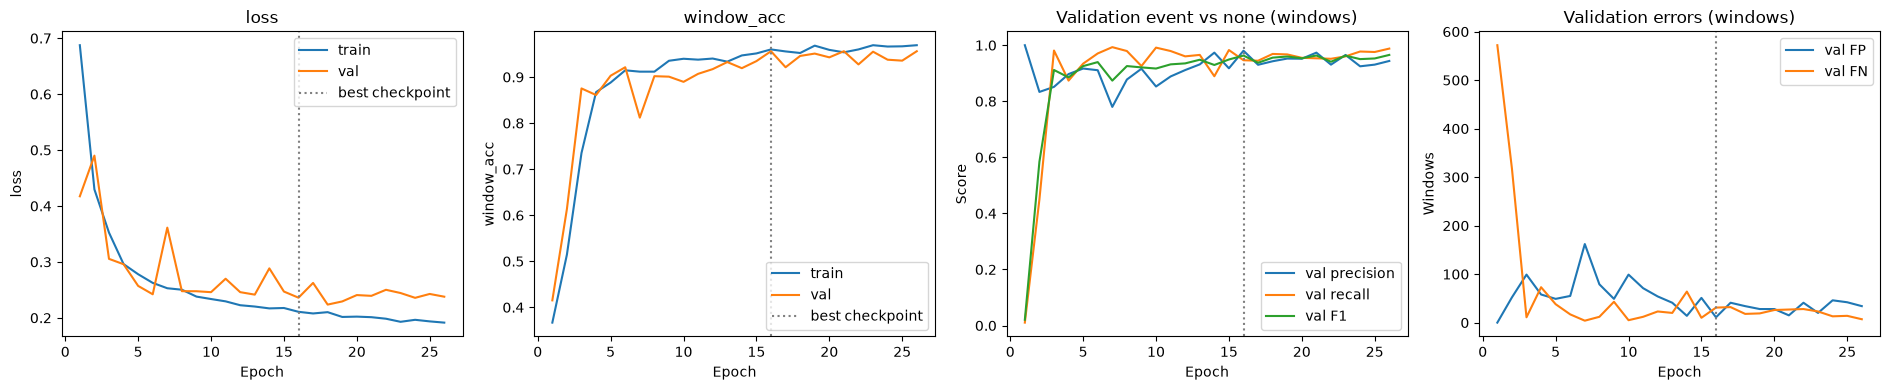

In [32]:
history_path = RUN_DIR / 'history.csv'
history = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()
if history.empty:
    print('No history.csv in this run. Re-run the matching training notebook from a fresh kernel and point RUN_DIR at that new run.')
else:
    fig, axes = plt.subplots(1, 4, figsize=(19, 4))
    for ax, metric in zip(axes[:2], ('loss', 'window_acc')):
        for split in ('train', 'val'):
            ax.plot(history.epoch, history[f'{split}_{metric}'], label=split)
        ax.axvline(checkpoint['epoch'], color='gray', linestyle=':', label='best checkpoint')
        ax.set(xlabel='Epoch', ylabel=metric, title=metric)
        ax.legend()
    if {'val_precision', 'val_recall'} <= set(history.columns):
        axes[2].plot(history.epoch, history.val_precision, label='val precision')
        axes[2].plot(history.epoch, history.val_recall, label='val recall')
        if {'val_tp', 'val_fp', 'val_fn'} <= set(history.columns):
            history['val_f1'] = 2*history.val_tp / (2*history.val_tp + history.val_fp + history.val_fn)
            axes[2].plot(history.epoch, history.val_f1, label='val F1')
        axes[2].axvline(checkpoint['epoch'], color='gray', linestyle=':')
        axes[2].set(xlabel='Epoch', ylabel='Score', title='Validation event vs none (windows)')
        axes[2].legend()
    if {'val_fp', 'val_fn'} <= set(history.columns):
        axes[3].plot(history.epoch, history.val_fp, label='val FP')
        axes[3].plot(history.epoch, history.val_fn, label='val FN')
        axes[3].axvline(checkpoint['epoch'], color='gray', linestyle=':')
        axes[3].set(xlabel='Epoch', ylabel='Windows', title='Validation errors (windows)')
        axes[3].legend()
    if 'lr' in history:
        print('Learning-rate schedule is available in history.lr')
    plt.tight_layout()
    plt.show()

In [33]:
history  # Filter by epoch; compare train_loss / val_loss and train_window_acc / val_window_acc.

,epoch,train_loss,train_frame_acc,train_window_acc,val_loss,val_frame_acc,val_window_acc,val_precision,val_recall,val_tp,val_fp,val_fn,val_tn,val_f1
0,1,0.687436,0.944191,0.366795,0.417309,0.984427,0.415133,1.000000,0.010381,6,0,572,400,0.020548
1,2,0.429591,0.982611,0.514479,0.490030,0.980181,0.613497,0.833333,0.449827,260,52,318,348,0.584270
2,3,0.352369,0.974833,0.735039,0.305431,0.965965,0.875256,0.851351,0.980969,567,99,11,301,0.911576
3,4,0.296079,0.973583,0.867278,0.295856,0.981667,0.860941,0.896980,0.873702,505,58,73,342,0.885188
4,5,0.277972,0.976747,0.888031,0.257105,0.979796,0.902863,0.916808,0.934256,540,49,38,351,0.925450
5,6,0.262495,0.979538,0.914575,0.242124,0.978821,0.921268,0.910714,0.970588,561,55,17,345,0.939698
6,7,0.252907,0.979302,0.911680,0.361269,0.938344,0.811861,0.779891,0.993080,574,162,4,238,0.873668
7,8,0.250288,0.979297,0.911680,0.247666,0.974523,0.901840,0.877519,0.979239,566,79,12,321,0.925593
8,9,0.237989,0.981139,0.935328,0.247571,0.983391,0.900818,0.916096,0.925606,535,49,43,351,0.920826
9,10,0.233641,0.979601,0.939672,0.245887,0.970474,0.889571,0.852679,0.991349,573,99,5,301,0.916800


## 2. Window-level diagnostics
Each observation is a 300-frame training/validation window. PR-AUC uses one event score per window: the maximum probability of either event class across the window. These are *not* alarm metrics.

In [34]:
def divide(a, b):
    return float(a / b) if b else float('nan')

def ranking_metrics(truth, score):
    # Average precision = area under the stepwise precision-recall curve.
    truth, score = np.asarray(truth, dtype=bool), np.asarray(score)
    positives, negatives = truth.sum(), (~truth).sum()
    if not positives or not negatives:
        return dict(pr_auc=float('nan'), roc_auc=float('nan'))
    order = np.argsort(-score, kind='stable')
    y, s = truth[order], score[order]
    ends = np.r_[np.flatnonzero(s[:-1] != s[1:]), len(s) - 1]
    tp = np.cumsum(y)[ends]
    precision = tp / (ends + 1)
    pr_auc = np.sum(precision * np.diff(np.r_[0, tp / positives]))
    ranks = rankdata(score, method='average')
    roc_auc = (ranks[truth].sum() - positives * (positives + 1) / 2) / (positives * negatives)
    return dict(pr_auc=float(pr_auc), roc_auc=float(roc_auc))

def binary_metrics(truth, predicted):
    truth, predicted = np.asarray(truth, dtype=bool), np.asarray(predicted, dtype=bool)
    tp, fp = int((truth & predicted).sum()), int((~truth & predicted).sum())
    fn, tn = int((truth & ~predicted).sum()), int((~truth & ~predicted).sum())
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, precision=divide(tp, tp+fp),
                recall=divide(tp, tp+fn), f1=divide(2*tp, 2*tp+fp+fn),
                specificity=divide(tn, tn+fp), accuracy=divide(tp+tn, len(truth)),
                balanced_acc=np.nanmean([divide(tp, tp+fn), divide(tn, tn+fp)]))

LABEL_DELAY_FRAMES = int(checkpoint.get('positive_label_delay_frames', 0))

def shift_event_targets_right(frame_labels, shift):
    """Move event probabilities later and assign remaining mass to none."""
    if shift < 0:
        raise ValueError('shift must be non-negative')
    if shift == 0:
        return frame_labels
    if shift >= frame_labels.shape[1]:
        raise ValueError('shift must be smaller than the number of frames')
    shifted = torch.zeros_like(frame_labels)
    shifted[..., 0] = 1.0
    shifted[:, shift:, 1:] = frame_labels[:, :-shift, 1:]
    shifted[..., 0] = 1.0 - shifted[..., 1:].sum(dim=-1)
    return shifted

@torch.no_grad()
def evaluate_checkpoint(model, loader, device, threshold, event_weight, neg_window_weight):
    """Reproduce validation metrics using the checkpoint's delayed soft targets."""
    model.eval()
    total_loss = correct_frames = total_frames = correct_windows = total_windows = 0
    tp = fp = fn = tn = 0
    for batch in loader:
        imu = batch['imu'].to(device)
        frame_labels = shift_event_targets_right(
            batch['frame_labels'].to(device), LABEL_DELAY_FRAMES
        )
        window_labels = batch['window_label'].to(device)
        logits, _ = model(imu)
        probs = torch.softmax(logits, dim=-1)
        loss = frame_soft_ce(
            logits, frame_labels, event_weight, window_label=window_labels,
            neg_window_weight=neg_window_weight,
        )
        total_loss += loss.item() * imu.size(0)
        pred = probs.argmax(dim=-1)
        true_cls = frame_labels.argmax(dim=-1)
        correct_frames += (pred == true_cls).sum().item()
        total_frames += true_cls.numel()
        window_pred = window_class_from_probs(probs, threshold)
        correct_windows += (window_pred == window_labels).sum().item()
        total_windows += imu.size(0)
        for wp, wl in zip(window_pred > 0, window_labels > 0):
            if wp and wl:
                tp += 1
            elif wp:
                fp += 1
            elif wl:
                fn += 1
            else:
                tn += 1
    n = len(loader.dataset)
    return dict(loss=total_loss / n, frame_acc=correct_frames / total_frames,
                window_acc=correct_windows / total_windows,
                precision=tp / (tp + fp + 1e-8), recall=tp / (tp + fn + 1e-8),
                tp=tp, fp=fp, fn=fn, tn=tn)

_, val_ds = build_datasets(cfg)
val_loader = DataLoader(val_ds, batch_size=cfg.training.batch_size, shuffle=False)
saved_metrics = checkpoint['val_metrics']
measured_metrics = evaluate_checkpoint(model, val_loader, torch.device('cpu'),
                            cfg.training.prediction_threshold, cfg.training.event_loss_weight,
                            cfg.training.neg_window_weight)
metric_keys = ('loss', 'frame_acc', 'window_acc', 'precision', 'recall', 'tp', 'fp', 'fn', 'tn')
metric_reproduction = pd.DataFrame([
    {'metric': key, 'saved': saved_metrics[key], 'current': measured_metrics[key],
     'matches': np.isclose(saved_metrics[key], measured_metrics[key], atol=1e-6)}
    for key in metric_keys
])
if EVALUATION_DATA_ROOT is None and metric_reproduction['matches'].all():
    print('Saved validation metrics independently reproduced.')
elif EVALUATION_DATA_ROOT is not None:
    print('Evaluation-data override is active; saved training-validation metrics are not expected to reproduce.')
else:
    print('Saved validation metrics differ from the current data. The checkpoint does not '
          'store input-label or exclusion-registry contents; compare the saved and current values below.')
print(metric_reproduction.to_string(index=False))
window_rows = []
with torch.inference_mode():
    for index in range(len(val_ds)):
        sample = val_ds[index]
        probs = model(sample['imu'].unsqueeze(0))[0].softmax(-1)
        event = probs[0, :, 1:]
        score = event.max().item()
        predicted = int(window_class_from_probs(probs, cfg.training.prediction_threshold)[0])
        window_rows.append(dict(index=index, file=val_ds.window_meta[index].source_file,
                                true=int(sample['window_label']), pred=predicted,
                                event_score=score, peak_local_frame=int(event.max(-1).values.argmax()),
                                true_global_frame=val_ds.window_meta[index].trigger_frame))
windows = pd.DataFrame(window_rows)
window_summary = pd.DataFrame([binary_metrics(windows.true > 0, windows.pred > 0) |
                               ranking_metrics(windows.true > 0, windows.event_score) |
                               dict(window_3class_accuracy=float((windows.true == windows.pred).mean()))])
window_summary

Train dirs:
  /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/TapRecognition/data_05_10_26/train_data
  Excluding session(s) [8] from imuStrict_Miguel_knock_twice_left_20260929_115133.csv
  Excluding session(s) [15] from imu_Miguel_knock_twice_left_20260924_093125.csv
  Excluding session(s) [2, 6, 12, 13, 16, 19] from imu_Miguel_knock_twice_left_20260925_105524.csv
  Excluding session(s) [1, 6, 7, 10, 17, 19] from imu_Miguel_knock_twice_left_20260925_152309.csv
  Excluding session(s) [10, 19] from imu_Miguel_knock_twice_right_20260923_113114.csv
  Excluding session(s) [2, 9] from imu_Miguel_knock_twice_right_20260924_093233.csv
  Excluding session(s) [4, 9, 13, 14, 16, 18, 19, 20] from imu_Miguel_knock_twice_right_20260925_105401.csv
  Excluding session(s) [19] from imu_Miguel_knock_twice_right_20260925_152103.csv
  Excluding session(s) [1] from imu_OLV_knock_twice_left_20260923_174506.csv
Val dirs:
  /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/T

,tp,fp,fn,tn,precision,recall,f1,specificity,accuracy,balanced_acc,pr_auc,roc_auc,window_3class_accuracy
0,535,11,31,389,0.979853,0.94523,0.96223,0.9725,0.956522,0.958865,0.993562,0.989342,0.956522


In [35]:
window_cm = pd.crosstab(windows.true, windows.pred, rownames=['true'], colnames=['predicted'])
window_cm = window_cm.reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
per_class = pd.DataFrame([dict(class_id=c, precision=divide(window_cm.loc[c, c], window_cm[c].sum()),
                               recall=divide(window_cm.loc[c, c], window_cm.loc[c].sum()),
                               f1=divide(2*window_cm.loc[c, c], window_cm[c].sum()+window_cm.loc[c].sum()),
                               support=int(window_cm.loc[c].sum())) for c in (0, 1, 2)])
correct_positive = windows[(windows.true > 0) & (windows.pred > 0)]
print('3-class confusion matrix (rows=true, columns=predicted)')
display(window_cm)
print('Side accuracy given an event was detected:',
      divide((correct_positive.true == correct_positive.pred).sum(), len(correct_positive)))
per_class

3-class confusion matrix (rows=true, columns=predicted)


predicted,0,1,2
true,,,
0,389,8,3
1,14,262,0
2,17,0,273


Side accuracy given an event was detected: 1.0


,class_id,precision,recall,f1,support
0,0,0.92619,0.972500,0.948780,400
1,1,0.97037,0.949275,0.959707,276
2,2,0.98913,0.941379,0.964664,290


In [36]:
windows  # Filter file, true, pred, event_score and peak_local_frame to inspect individual errors.

,index,file,true,pred,event_score,peak_local_frame,true_global_frame
0,0,imuStrict_Miguel_knock_twice_left_20260929_115...,1,1,0.875163,253,244.0
1,1,imuStrict_Miguel_knock_twice_left_20260929_115...,1,1,0.870322,260,562.0
2,2,imuStrict_Miguel_knock_twice_left_20260929_115...,1,1,0.873565,255,851.0
3,3,imuStrict_Miguel_knock_twice_left_20260929_115...,1,1,0.825380,251,1152.0
4,4,imuStrict_Miguel_knock_twice_left_20260929_115...,1,1,0.845681,247,1458.0
...,...,...,...,...,...,...,...
961,961,imu_ZR_switch_hand_20260909_092838.csv,0,0,0.038503,50,NaN
962,962,imu_ZR_switch_hand_20260909_092838.csv,0,0,0.010402,35,NaN
963,963,imu_ZR_switch_hand_20260909_092838.csv,0,0,0.148250,32,NaN
964,964,imu_ZR_switch_hand_20260909_092838.csv,0,0,0.068575,43,NaN


## 3. Whole-recording causal frame probabilities
The model state persists within a recording, resets only between recordings, and the high-pass filter is applied once per recording. Frame targets are *hard regions* around each second tap (±10 frames), distinct from the soft labels used for training. Frame accuracy is dominated by background and remains secondary.

In [37]:
all_recordings, recording_audit, data_manifest = load_recordings(ROOT, evaluation_data, cfg.labels.half_frames)
recordings = [r for r in all_recordings if r.split == 'valid']
assert len(recordings) > 0
probabilities, frame_parts = {}, []
with torch.inference_mode():
    for rec in recordings:
        x = torch.from_numpy(rec.imu).unsqueeze(0)
        logits, _ = model(x)
        # Independent causal reference: only new CNN features advance the recurrent state.
        # Full/chunked float32 kernels can accumulate small rounding differences.
        sizes = [min(128, x.shape[1] - i) for i in range(0, x.shape[1], 128)]
        torch.testing.assert_close(overlap_stream_logits(model, x, sizes), logits, atol=1e-4, rtol=1e-4,
                                   msg=lambda message: f'{rec.path.name}: full/chunked inference differs\n{message}')
        p = logits[0].softmax(-1).numpy()
        probabilities[rec.path.name] = p
        target = np.zeros(len(p), dtype=np.int8)
        for frame, _ in rec.events:
            target[max(0, frame-10):min(len(p), frame+11)] = 1
        frame_parts.append(pd.DataFrame(dict(file=rec.path.name, user=rec.user, action=rec.action,
                                             frame=np.arange(len(p)), true=target,
                                             p_none=p[:, 0], p_left=p[:, 1], p_right=p[:, 2],
                                             event_score=p[:, 1:].max(axis=1))))
frames = pd.concat(frame_parts, ignore_index=True)
frame_summary = pd.DataFrame([binary_metrics(frames.true, frames.event_score >= cfg.training.prediction_threshold) |
                              ranking_metrics(frames.true, frames.event_score)])
frame_summary

,tp,fp,fn,tn,precision,recall,f1,specificity,accuracy,balanced_acc,pr_auc,roc_auc
0,3275,2781,8611,277979,0.540786,0.275534,0.365065,0.990095,0.961072,0.632814,0.425268,0.94885


In [38]:
frames[(frames['event_score'] > 0.8) & (frames['true'] == 0)]  # Each row is a real recorded frame; filter file and frame range for detailed inspection.

,file,user,action,frame,true,p_none,p_left,p_right,event_score
862,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,862,0,0.138748,0.860977,0.000275,0.860977
863,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,863,0,0.198425,0.801205,0.000369,0.801205
2676,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,2676,0,0.148801,0.851062,0.000137,0.851062
2677,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,2677,0,0.172346,0.827461,0.000193,0.827461
2972,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,2972,0,0.115892,0.883949,0.000160,0.883949
...,...,...,...,...,...,...,...,...,...
198360,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,2061,0,0.179319,0.001161,0.819520,0.819520
201390,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,5091,0,0.172085,0.001118,0.826796,0.826796
201391,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,5092,0,0.155785,0.000681,0.843533,0.843533
201392,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,5093,0,0.183537,0.000504,0.815959,0.815959


## 4. Streaming alarms and one-to-one event matching
Two *predeclared* policies: `instant` emits on the first crossing (no look-ahead); `lookahead_12f` waits 12 frames like the current default detector. Both require one frame above threshold and enforce a 0.5 s refractory period measured from the selected probability peak. A correct-side alarm is matched one-to-one to a labeled tap when emitted from **20 frames early through 30 frames late**, inclusive. The early allowance accommodates annotation timing errors and applies to all event metrics and threshold selection. Stricter late deadlines are analyzed next. Do not tune a threshold on validation and then call that same validation performance an unbiased test result.

In [39]:
THRESHOLDS = np.round(np.arange(0.10, 1.01, 0.01), 2)  # includes the training threshold 0.50
POLICIES = {'lookahead_12f': 12}
MAX_LATE_FRAMES = 30
EARLY_ALLOWANCE_FRAMES = 20  # Accept annotation timing error: -20 <= alarm_frame - label_frame <= 30.

def emit_alarms(probs, threshold, look, refractory):
    # All decisions use information available at the emission frame, never future frames.
    alarms, i, n = [], 0, len(probs)
    while i < n:
        score = probs[i, 1:].max()
        if score < threshold:
            i += 1
            continue
        emission = i + look
        if emission >= n:  # An offline end-of-file flush is not an online alarm.
            break
        peak = i + int(probs[i:emission+1, 1:].max(axis=1).argmax())
        cls = int(probs[peak, 1:].argmax() + 1)
        alarms.append(dict(alarm_frame=emission, peak_frame=peak, class_id=cls,
                           probability=float(probs[peak, cls])))
        # Match the detector's lockout: it is measured from the selected peak.
        i = max(emission + 1, peak + max(1, refractory))
    return alarms

def match_alarms(truth, alarms, class_aware=True, early_allowance=None):
    # Min-cost 1:1 assignment: prefer matching as many events as possible, then closest timing.
    if early_allowance is None:
        early_allowance = EARLY_ALLOWANCE_FRAMES
    n, m = len(truth), len(alarms)
    if not n or not m:
        return []
    cost = np.full((n, m+n), 1e6, dtype=float)
    cost[:, m:] = 1e3
    for a, (frame, cls) in enumerate(truth):
        for b, alarm in enumerate(alarms):
            delta = alarm['alarm_frame'] - frame
            if -early_allowance <= delta <= MAX_LATE_FRAMES and (not class_aware or cls == alarm['class_id']):
                cost[a, b] = abs(delta)
    rows, cols = linear_sum_assignment(cost)
    return [(int(a), int(b)) for a, b in zip(rows, cols) if b < m and cost[a, b] < 1e3]

assert not match_alarms([(100, 1)], [dict(alarm_frame=79, class_id=1)])
assert len(match_alarms([(100, 1)], [dict(alarm_frame=80, class_id=1)])) == 1
assert len(match_alarms([(100, 1)], [dict(alarm_frame=98, class_id=1)])) == 1
assert len(match_alarms([(100, 1)], [dict(alarm_frame=130, class_id=1)])) == 1
assert not match_alarms([(100, 1)], [dict(alarm_frame=131, class_id=1)])
assert not match_alarms([(100, 1)], [dict(alarm_frame=80, class_id=2)])
assert not match_alarms([(100, 1)], [dict(alarm_frame=100, class_id=2)])
assert len(match_alarms([(100, 1)], [dict(alarm_frame=98, class_id=1),
                                   dict(alarm_frame=101, class_id=1)])) == 1
assert emit_alarms(np.array([[0., 1., 0.], [0., 1., 0.]]), .5, 0, 5)[0]['alarm_frame'] == 0

session_rows, alarm_rows, truth_rows = [], [], []
for rec in recordings:
    probs = probabilities[rec.path.name]
    minutes = len(probs) / rec.fs / 60
    for policy, look in POLICIES.items():
        for threshold in THRESHOLDS:
            threshold = float(threshold)
            detected = emit_alarms(probs, threshold, look, round(.5 * rec.fs))
            matches = match_alarms(rec.events, detected)
            binary_matches = match_alarms(rec.events, detected, class_aware=False)
            matched_truth = {a: b for a, b in matches}
            matched_alarms = {b: a for a, b in matches}
            session_rows.append(dict(file=rec.path.name, user=rec.user, action=rec.action,
                                     policy=policy, threshold=threshold, minutes=minutes,
                                     n_true=len(rec.events), n_alarms=len(detected),
                                     tp=len(matches), fp=len(detected)-len(matches),
                                     fn=len(rec.events)-len(matches),
                                     binary_tp=len(binary_matches),
                                     binary_fp=len(detected)-len(binary_matches),
                                     binary_fn=len(rec.events)-len(binary_matches)))
            for a, (frame, cls) in enumerate(rec.events):
                alarm = detected[matched_truth[a]] if a in matched_truth else None
                truth_rows.append(dict(file=rec.path.name, user=rec.user, action=rec.action,
                                       policy=policy, threshold=threshold, true_frame=frame, true_class=cls,
                                       detected=alarm is not None, alarm_frame=alarm['alarm_frame'] if alarm else np.nan,
                                       latency_frames=alarm['alarm_frame']-frame if alarm else np.nan,
                                       fs=rec.fs))
            for b, alarm in enumerate(detected):
                a = matched_alarms.get(b)
                closest = min(rec.events, key=lambda event: abs(alarm['alarm_frame']-event[0])) if rec.events else None
                nearest_delta = alarm['alarm_frame'] - closest[0] if closest else np.nan
                alarm_rows.append(dict(file=rec.path.name, user=rec.user, action=rec.action,
                                       policy=policy, threshold=threshold, **alarm,
                                       matched=a is not None, true_frame=rec.events[a][0] if a is not None else np.nan,
                                       latency_frames=alarm['alarm_frame']-rec.events[a][0] if a is not None else np.nan,
                                       nearest_true_frame=closest[0] if closest else np.nan,
                                       delta_to_nearest_true=nearest_delta,
                                       too_early=bool(nearest_delta < -EARLY_ALLOWANCE_FRAMES) if closest else False))
sessions = pd.DataFrame(session_rows)
alarms = pd.DataFrame(alarm_rows)
truth_events = pd.DataFrame(truth_rows)
print('Validation recordings:', len(recordings), '| positive events:', len([e for r in recordings for e in r.events]))

with pd.option_context('display.max_colwidth', None):
    display(sessions[(sessions['threshold'] == 0.5) & (sessions['policy'] == 'lookahead_12f')])


Validation recordings: 49 | positive events: 566


,file,user,action,policy,threshold,minutes,n_true,n_alarms,tp,fp,fn,binary_tp,binary_fp,binary_fn
40,imuStrict_Miguel_knock_twice_left_20260929_115836.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.010500,20,20,20,0,0,20,0,0
131,imuStrict_Miguel_knock_twice_left_20260929_153217.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.010167,20,19,19,0,1,19,0,1
222,imuStrict_Miguel_knock_twice_left_20260929_153518.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.010667,20,20,20,0,0,20,0,0
313,imuStrict_Miguel_knock_twice_left_20260930_150247.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.010500,20,22,19,3,1,19,3,1
404,imuStrict_Miguel_knock_twice_left_20260930_150531.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.009667,20,19,18,1,2,18,1,2
495,imuStrict_Miguel_knock_twice_left_20260930_151103.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.010500,20,20,20,0,0,20,0,0
586,imuStrict_Miguel_knock_twice_left_20261002_105241.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.009667,20,20,18,2,2,18,2,2
677,imuStrict_Miguel_knock_twice_left_20261002_110333.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.008667,20,22,17,5,3,17,5,3
768,imuStrict_Miguel_knock_twice_left_20261005_152232.csv,Miguel,knock_twice_left,lookahead_12f,0.5,1.010333,20,21,19,2,1,19,2,1
859,imuStrict_Miguel_knock_twice_right_20260929_114726.csv,Miguel,knock_twice_right,lookahead_12f,0.5,1.009833,20,20,19,1,1,19,1,1


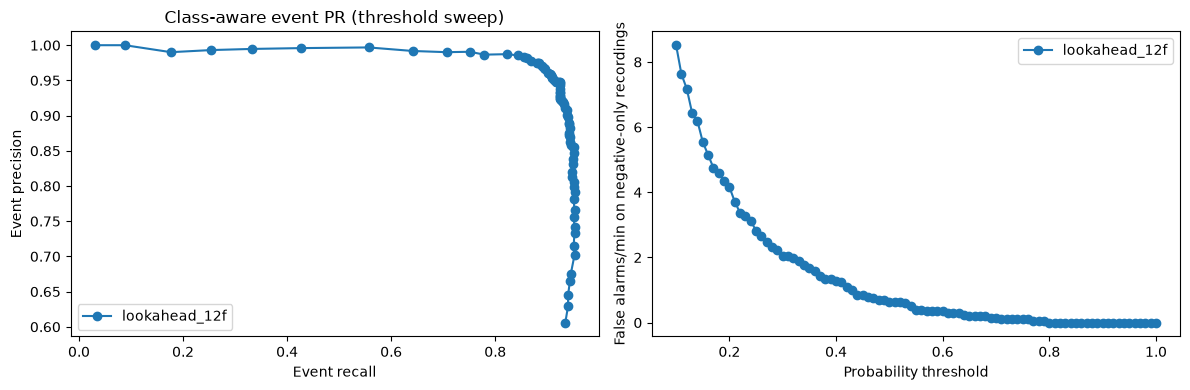

In [40]:
event_rows = []
for (policy, threshold), group in sessions.groupby(['policy', 'threshold'], sort=True):
    tp, fp, fn = (int(group[col].sum()) for col in ('tp', 'fp', 'fn'))
    bt, bp, bn = (int(group[col].sum()) for col in ('binary_tp', 'binary_fp', 'binary_fn'))
    negative = group[group.n_true == 0]
    event_rows.append(dict(policy=policy, threshold=threshold, tp=tp, fp=fp, fn=fn,
                           precision=divide(tp, tp+fp), recall=divide(tp, tp+fn),
                           f1=divide(2*tp, 2*tp+fp+fn),
                           binary_f1=divide(2*bt, 2*bt+bp+bn),
                           fp_per_min=divide(fp, group.minutes.sum()),
                           negative_fp_per_min=divide(negative.fp.sum(), negative.minutes.sum())))
event_summary = pd.DataFrame(event_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for policy, group in event_summary.groupby('policy'):
    axes[0].plot(group.recall, group.precision, 'o-', label=policy)
    axes[1].plot(group.threshold, group.negative_fp_per_min, 'o-', label=policy)
axes[0].set(xlabel='Event recall', ylabel='Event precision', title='Class-aware event PR (threshold sweep)')
axes[1].set(xlabel='Probability threshold', ylabel='False alarms/min on negative-only recordings')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

In [41]:
event_summary  # Compare threshold, instant vs lookahead, class-aware F1, binary F1 and FP/min.

,policy,threshold,tp,fp,fn,precision,recall,f1,binary_f1,fp_per_min,negative_fp_per_min
0,lookahead_12f,0.10,529,344,37,0.605956,0.934629,0.735233,0.739402,7.052890,8.515905
1,lookahead_12f,0.11,532,313,34,0.629586,0.939929,0.754075,0.756910,6.417310,7.624706
2,lookahead_12f,0.12,532,293,34,0.644848,0.939929,0.764917,0.767793,6.007258,7.179106
3,lookahead_12f,0.13,534,269,32,0.665006,0.943463,0.780131,0.783053,5.515196,6.436440
4,lookahead_12f,0.14,535,257,31,0.675505,0.945230,0.787923,0.790869,5.269165,6.188885
...,...,...,...,...,...,...,...,...,...,...,...
86,lookahead_12f,0.96,0,0,566,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
87,lookahead_12f,0.97,0,0,566,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
88,lookahead_12f,0.98,0,0,566,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
89,lookahead_12f,0.99,0,0,566,NaN,0.000000,0.000000,0.000000,0.000000,0.000000


In [42]:
sessions  # Filter threshold, policy, user, action or file to see where errors occur.

,file,user,action,policy,threshold,minutes,n_true,n_alarms,tp,fp,fn,binary_tp,binary_fp,binary_fn
0,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.10,1.010500,20,20,20,0,0,20,0,0
1,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.11,1.010500,20,20,20,0,0,20,0,0
2,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.12,1.010500,20,20,20,0,0,20,0,0
3,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.13,1.010500,20,20,20,0,0,20,0,0
4,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.14,1.010500,20,20,20,0,0,20,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4454,imu_ZR_switch_hand_20260909_092838.csv,ZR,switch_hand,lookahead_12f,0.96,1.010167,0,0,0,0,0,0,0,0
4455,imu_ZR_switch_hand_20260909_092838.csv,ZR,switch_hand,lookahead_12f,0.97,1.010167,0,0,0,0,0,0,0,0
4456,imu_ZR_switch_hand_20260909_092838.csv,ZR,switch_hand,lookahead_12f,0.98,1.010167,0,0,0,0,0,0,0,0
4457,imu_ZR_switch_hand_20260909_092838.csv,ZR,switch_hand,lookahead_12f,0.99,1.010167,0,0,0,0,0,0,0,0


In [43]:
alarms[(alarms['true_frame'].isna()) & (alarms['policy'] == 'instant') & (alarms['delta_to_nearest_true'] > -20) & (alarms['threshold'] >= 0.5)].sort_values(by=['delta_to_nearest_true', 'probability']) # Filter too_early == True, threshold, policy, file or matched == False.

,file,user,action,policy,threshold,alarm_frame,peak_frame,class_id,probability,matched,true_frame,latency_frames,nearest_true_frame,delta_to_nearest_true,too_early


In [44]:
alarms[alarms.too_early]  # Alarms earlier than the configured annotation allowance.

,file,user,action,policy,threshold,alarm_frame,peak_frame,class_id,probability,matched,true_frame,latency_frames,nearest_true_frame,delta_to_nearest_true,too_early
1526,imuStrict_Miguel_knock_twice_left_20260929_153...,Miguel,knock_twice_left,lookahead_12f,0.10,3164,3160,2,0.267358,False,NaN,NaN,3280.0,-116.0,True
1549,imuStrict_Miguel_knock_twice_left_20260929_153...,Miguel,knock_twice_left,lookahead_12f,0.11,3167,3160,2,0.267358,False,NaN,NaN,3280.0,-113.0,True
1572,imuStrict_Miguel_knock_twice_left_20260929_153...,Miguel,knock_twice_left,lookahead_12f,0.12,3168,3160,2,0.267358,False,NaN,NaN,3280.0,-112.0,True
1595,imuStrict_Miguel_knock_twice_left_20260929_153...,Miguel,knock_twice_left,lookahead_12f,0.13,3168,3160,2,0.267358,False,NaN,NaN,3280.0,-112.0,True
1618,imuStrict_Miguel_knock_twice_left_20260929_153...,Miguel,knock_twice_left,lookahead_12f,0.14,3169,3160,2,0.267358,False,NaN,NaN,3280.0,-111.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43429,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,0.69,2345,2334,2,0.732504,False,NaN,NaN,2369.0,-24.0,True
43445,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,0.70,2346,2334,2,0.732504,False,NaN,NaN,2369.0,-23.0,True
43461,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,0.71,2346,2334,2,0.732504,False,NaN,NaN,2369.0,-23.0,True
43477,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,0.72,2346,2334,2,0.732504,False,NaN,NaN,2369.0,-23.0,True


In [45]:
class_rows = []
for (policy, threshold), positives in truth_events.groupby(['policy', 'threshold']):
    predictions = alarms[(alarms.policy == policy) & (alarms.threshold == threshold)]
    for cls in (1, 2):
        target = positives[positives.true_class == cls]
        classified = predictions[predictions.class_id == cls]
        tp = int(target.detected.sum())
        fp, fn = len(classified)-tp, len(target)-tp
        class_rows.append(dict(policy=policy, threshold=threshold, class_id=cls,
                               support=len(target), tp=tp, fp=fp, fn=fn,
                               precision=divide(tp, tp+fp), recall=divide(tp, tp+fn),
                               f1=divide(2*tp, 2*tp+fp+fn)))
event_per_class = pd.DataFrame(class_rows)
event_per_class  # Per-class detection performance, including wrong-side alarms as FP + FN.

,policy,threshold,class_id,support,tp,fp,fn,precision,recall,f1
0,lookahead_12f,0.10,1,276,257,177,19,0.592166,0.931159,0.723944
1,lookahead_12f,0.10,2,290,272,167,18,0.619590,0.937931,0.746228
2,lookahead_12f,0.11,1,276,259,160,17,0.618138,0.938406,0.745324
3,lookahead_12f,0.11,2,290,273,153,17,0.640845,0.941379,0.762570
4,lookahead_12f,0.12,1,276,258,150,18,0.632353,0.934783,0.754386
...,...,...,...,...,...,...,...,...,...,...
177,lookahead_12f,0.98,2,290,0,0,290,NaN,0.000000,0.000000
178,lookahead_12f,0.99,1,276,0,0,276,NaN,0.000000,0.000000
179,lookahead_12f,0.99,2,290,0,0,290,NaN,0.000000,0.000000
180,lookahead_12f,1.00,1,276,0,0,276,NaN,0.000000,0.000000


### Why can raising the instant threshold *increase* recall?
A higher threshold can move the **first crossing later**, from before the labeled tap into the valid interval. A lower threshold can also start the 0.5 s refractory period too soon, suppressing a later alarm. Thus detection recall after timing-based matching is not necessarily monotonic in the threshold.

The primary scores accept alarms up to **20 frames early** (200 ms at 100 Hz) to accommodate annotation timing errors. The dashed curve below re-scores the same emitted alarms with the old one-frame early allowance for reference. `too_early_fp` counts unmatched alarms earlier than the configured allowance before their nearest annotated tap; those alarms can be inspected in `alarms`.

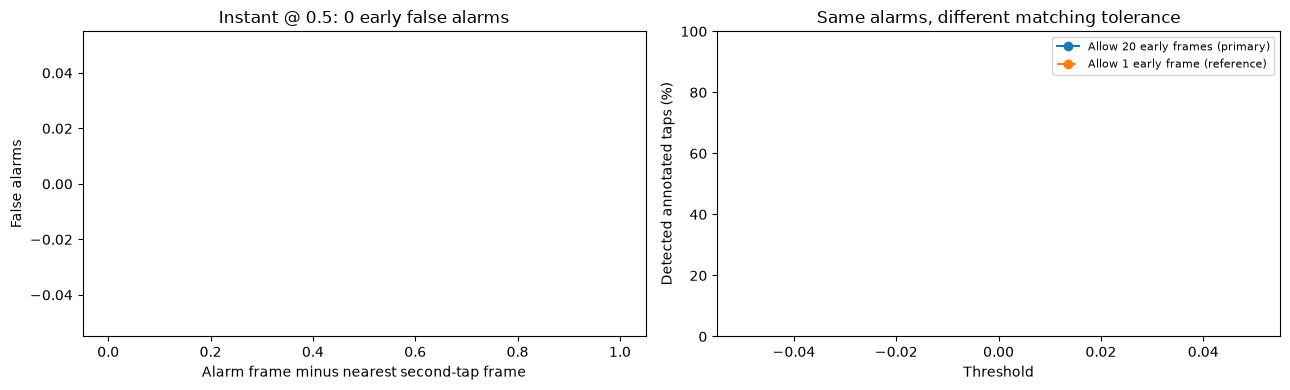

In [46]:
recording_by_file = {rec.path.name: rec for rec in recordings}
sensitivity_rows = []
for (policy, threshold), group in sessions.groupby(['policy', 'threshold']):
    selected_alarms = alarms[(alarms.policy == policy) & (alarms.threshold == threshold)]
    strict_tp = 0
    for file in group.file:
        rec = recording_by_file[file]
        emitted = selected_alarms[selected_alarms.file == file].to_dict('records')
        strict_tp += len(match_alarms(rec.events, emitted, early_allowance=1))
    primary_tp = int(group.tp.sum())
    primary_fp = int(group.fp.sum())
    assert primary_tp >= strict_tp
    total_taps = int(group.n_true.sum())
    too_early_fp = int((selected_alarms.too_early & ~selected_alarms.matched).sum())
    sensitivity_rows.append(dict(policy=policy, threshold=threshold, annotated=total_taps,
                                 primary_tp=primary_tp, primary_fp=primary_fp, too_early_fp=too_early_fp,
                                 primary_recall=divide(primary_tp, total_taps),
                                 strict_1f_recall=divide(strict_tp, total_taps)))
timing_sensitivity = pd.DataFrame(sensitivity_rows)
early_at_default = alarms[(alarms.policy == 'instant') &
                          (alarms.threshold == cfg.training.prediction_threshold) &
                          (~alarms.matched) & alarms.too_early]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(early_at_default.delta_to_nearest_true, bins=30, color='tab:orange')
axes[0].set(xlabel='Alarm frame minus nearest second-tap frame', ylabel='False alarms',
            title=f'Instant @ 0.5: {len(early_at_default)} early false alarms')
instant_diag = timing_sensitivity[timing_sensitivity.policy == 'instant']
axes[1].plot(instant_diag.threshold, instant_diag.primary_recall * 100, 'o-',
             label=f'Allow {EARLY_ALLOWANCE_FRAMES} early frames (primary)')
axes[1].plot(instant_diag.threshold, instant_diag.strict_1f_recall * 100, 'o--',
             label='Allow 1 early frame (reference)')
axes[1].set(xlabel='Threshold', ylabel='Detected annotated taps (%)', ylim=(0, 100),
            title='Same alarms, different matching tolerance')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [47]:
timing_sensitivity  # Filter threshold and policy; relaxed recall is NOT a valid production metric.

,policy,threshold,annotated,primary_tp,primary_fp,too_early_fp,primary_recall,strict_1f_recall
0,lookahead_12f,0.10,566,529,344,92,0.934629,0.809187
1,lookahead_12f,0.11,566,532,313,86,0.939929,0.816254
2,lookahead_12f,0.12,566,532,293,78,0.939929,0.821555
3,lookahead_12f,0.13,566,534,269,74,0.943463,0.830389
4,lookahead_12f,0.14,566,535,257,70,0.945230,0.835689
...,...,...,...,...,...,...,...,...
86,lookahead_12f,0.96,566,0,0,0,0.000000,0.000000
87,lookahead_12f,0.97,566,0,0,0,0.000000,0.000000
88,lookahead_12f,0.98,566,0,0,0,0.000000,0.000000
89,lookahead_12f,0.99,566,0,0,0,0.000000,0.000000


## 5. Latency and recall before a deadline
Latency is `alarm_frame - labeled_second_tap_frame`; negative values are early. The primary event score accepts alarms from **20 frames early through 30 frames late**, inclusive, to accommodate annotation timing errors. **Deadline recall (%) = matched alarms emitted before X frames / all annotated second taps**, including missed taps in the denominator. Strict `<5` therefore accepts matched alarms from −20 through +4 frames. Accepted early alarms also count toward timely recall; their signed latency is retained in the summaries and histograms. At 100 Hz, 20 frames = 200 ms. The histograms include only matched TPs.

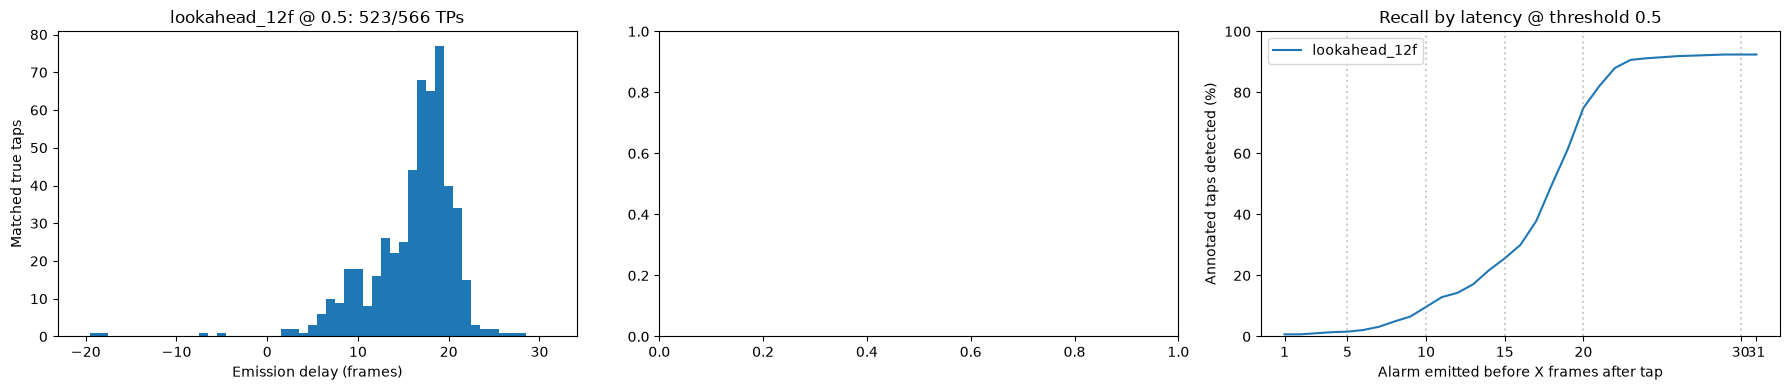

In [48]:
DEADLINES = (5, 10, 15, 20, 30)
latency_rows = []
for (policy, threshold), group in truth_events.groupby(['policy', 'threshold']):
    matched = group[group.detected]
    lat = matched.latency_frames.to_numpy()
    row = dict(policy=policy, threshold=threshold, annotated=len(group), matched=len(matched),
               mean_frames=np.mean(lat) if len(lat) else np.nan,
               median_frames=np.median(lat) if len(lat) else np.nan,
               p90_frames=np.percentile(lat, 90) if len(lat) else np.nan,
               mean_ms=np.mean(lat / matched.fs.to_numpy() * 1000) if len(lat) else np.nan,
               early_matches=int((lat < 0).sum()))
    for deadline in DEADLINES:
        row[f'recall_lt_{deadline}f'] = divide(int((lat < deadline).sum()), len(group))
    latency_rows.append(row)
latency_summary = pd.DataFrame(latency_rows)
# Every latency budget for every threshold/policy, with all missed taps in the denominator.
deadline_rows = []
for (policy, threshold), group in truth_events.groupby(['policy', 'threshold']):
    for budget in range(1, MAX_LATE_FRAMES + 2):
        found = int((group.detected & (group.latency_frames < budget)).sum())
        deadline_rows.append(dict(policy=policy, threshold=threshold, budget_frames=budget,
                                  found=found, annotated=len(group),
                                  percentage=100 * divide(found, len(group))))
deadline_curve = pd.DataFrame(deadline_rows)
for row in latency_summary.itertuples():
    for deadline in DEADLINES:
        curve_row = deadline_curve[(deadline_curve.policy == row.policy) &
                                   (deadline_curve.threshold == row.threshold) &
                                   (deadline_curve.budget_frames == deadline)]
        assert np.isclose(curve_row.percentage.iloc[0] / 100, getattr(row, f'recall_lt_{deadline}f'))
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, policy in zip(axes[:2], POLICIES):
    group = truth_events[(truth_events.policy == policy) &
                         (truth_events.threshold == cfg.training.prediction_threshold)]
    matched_latency = group.loc[group.detected, 'latency_frames']
    ax.hist(matched_latency, bins=np.arange(-EARLY_ALLOWANCE_FRAMES - .5, MAX_LATE_FRAMES + 2.5, 1), color='tab:blue')
    ax.set(xlabel='Emission delay (frames)', ylabel='Matched true taps',
           title=f'{policy} @ {cfg.training.prediction_threshold}: {len(matched_latency)}/{len(group)} TPs')
for policy, group in deadline_curve[deadline_curve.threshold == cfg.training.prediction_threshold].groupby('policy'):
    axes[2].plot(group.budget_frames, group.percentage, label=policy)
for deadline in DEADLINES:
    axes[2].axvline(deadline, color='gray', linestyle=':', alpha=.4)
axes[2].set(xlabel='Alarm emitted before X frames after tap',
            ylabel='Annotated taps detected (%)', ylim=(0, 100),
            xticks=[1, *DEADLINES, MAX_LATE_FRAMES + 1],
            title=f'Recall by latency @ threshold {cfg.training.prediction_threshold}')
axes[2].legend()
plt.tight_layout()
plt.show()

In [49]:
deadline_curve[(deadline_curve.threshold == cfg.training.prediction_threshold) &
               deadline_curve.budget_frames.isin(DEADLINES)]  # Full filterable table: deadline_curve.

,policy,threshold,budget_frames,found,annotated,percentage
1244,lookahead_12f,0.5,5,9,566,1.590106
1249,lookahead_12f,0.5,10,55,566,9.717314
1254,lookahead_12f,0.5,15,145,566,25.618375
1259,lookahead_12f,0.5,20,424,566,74.911661
1269,lookahead_12f,0.5,30,523,566,92.402827


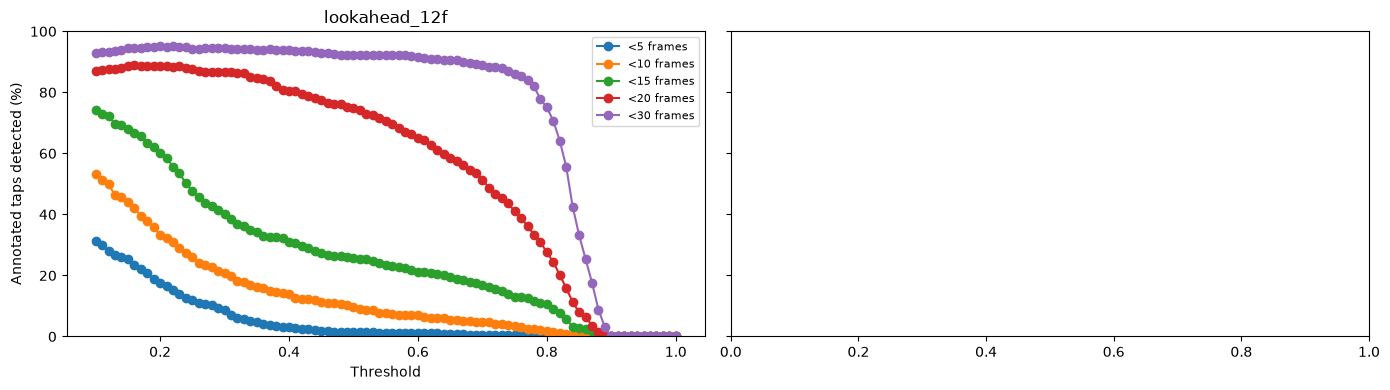

In [50]:
from matplotlib.ticker import MaxNLocator
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, policy in zip(axes, POLICIES):
    subset = latency_summary[latency_summary.policy == policy]
    for deadline in DEADLINES:
        ax.plot(subset.threshold, 100 * subset[f'recall_lt_{deadline}f'], 'o-', label=f'<{deadline} frames')
    ax.set(title=policy, xlabel='Threshold', ylabel='Annotated taps detected (%)',
           ylim=(0, 100))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [51]:
latency_summary  # All DEADLINES and thresholds, by policy; mean latency is conditional on matched events only.

,policy,threshold,annotated,matched,mean_frames,median_frames,p90_frames,mean_ms,early_matches,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f
0,lookahead_12f,0.10,566,529,7.434783,8.0,17.0,74.347826,85,0.312721,0.533569,0.743816,0.871025,0.927562
1,lookahead_12f,0.11,566,532,7.663534,8.0,17.0,76.635338,81,0.300353,0.514134,0.729682,0.874558,0.932862
2,lookahead_12f,0.12,566,532,7.921053,9.0,17.0,79.210526,79,0.279152,0.500000,0.722615,0.876325,0.932862
3,lookahead_12f,0.13,566,534,8.387640,10.0,17.0,83.876404,68,0.266784,0.462898,0.696113,0.876325,0.936396
4,lookahead_12f,0.14,566,535,8.534579,10.0,17.0,85.345794,66,0.261484,0.455830,0.692580,0.879859,0.938163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,lookahead_12f,0.96,566,0,NaN,NaN,NaN,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000
87,lookahead_12f,0.97,566,0,NaN,NaN,NaN,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000
88,lookahead_12f,0.98,566,0,NaN,NaN,NaN,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000
89,lookahead_12f,0.99,566,0,NaN,NaN,NaN,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000


In [52]:
truth_events  # Includes missed events (detected=False); filter latency_frames and user/action/file.

,file,user,action,policy,threshold,true_frame,true_class,detected,alarm_frame,latency_frames,fs
0,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.1,244,1,True,255.0,11.0,100.0
1,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.1,562,1,True,565.0,3.0,100.0
2,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.1,851,1,True,862.0,11.0,100.0
3,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.1,1152,1,True,1158.0,6.0,100.0
4,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,lookahead_12f,0.1,1458,1,True,1457.0,-1.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...
51501,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,1.0,4218,2,False,NaN,NaN,100.0
51502,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,1.0,4504,2,False,NaN,NaN,100.0
51503,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,1.0,4792,2,False,NaN,NaN,100.0
51504,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice_right,lookahead_12f,1.0,5080,2,False,NaN,NaN,100.0


## 6. Inspect one recording
Set `FILE` and `POLICY` below, then zoom with `START_FRAME` / `END_FRAME`. Red: annotated second tap. Green: actual alarm emission. Orange: probability peak selected for the alarm (may differ from emission). A correct-side alarm up to 20 frames before the annotation can be shown as a matched detection, with one alarm matched per tap.

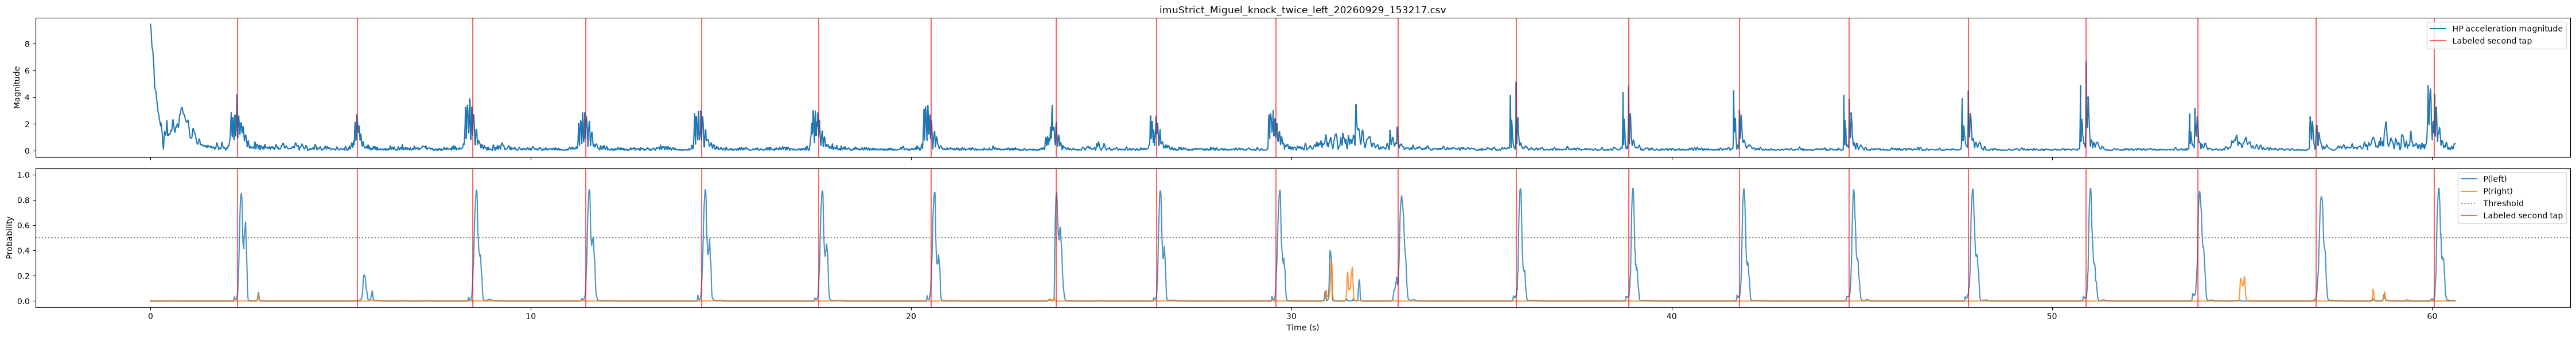

In [53]:
# FILE = next(r.path.name for r in recordings if r.events)  # or choose any file in sessions.file
FILE = 'imuStrict_Miguel_knock_twice_left_20260929_153217.csv'
POLICY = 'instant'
THRESHOLD = 0.5
rec = next(r for r in recordings if r.path.name == FILE)
# START_FRAME, END_FRAME = 0, len(rec.imu)  # e.g. 100, 450
START_FRAME, END_FRAME = 0, len(rec.imu)
p = probabilities[FILE]
selected = alarms[(alarms.file == FILE) & (alarms.policy == POLICY) &
                  (alarms.threshold == THRESHOLD)].copy()
x = np.arange(START_FRAME, END_FRAME) / rec.fs
fig, (ax, ap) = plt.subplots(2, 1, figsize=(45, 6), sharex=True)
ax.plot(x, np.linalg.norm(rec.imu[START_FRAME:END_FRAME, :3], axis=1), label='HP acceleration magnitude')
ax.set(ylabel='Magnitude', title=FILE)
ap.plot(x, p[START_FRAME:END_FRAME, 1], label='P(left)', alpha=.8)
ap.plot(x, p[START_FRAME:END_FRAME, 2], label='P(right)', alpha=.8)
ap.axhline(THRESHOLD, color='gray', linestyle=':', label='Threshold')
for frame, _ in rec.events:
    if START_FRAME <= frame < END_FRAME:
        for a in (ax, ap): a.axvline(frame/rec.fs, color='red', alpha=.6, label='Labeled second tap')
for row in selected.itertuples():
    if START_FRAME <= row.alarm_frame < END_FRAME:
        for a in (ax, ap): a.axvline(row.alarm_frame/rec.fs, color='green', alpha=.7, label='Alarm emission')
    if START_FRAME <= row.peak_frame < END_FRAME:
        ap.axvline(row.peak_frame/rec.fs, color='orange', alpha=.5, linestyle=':', label='Selected peak')
ap.set(xlabel='Time (s)', ylabel='Probability', ylim=(-.05, 1.05))
for a in (ax, ap):
    handles, labels = a.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    a.legend(unique.values(), unique.keys(), loc='upper right')
plt.tight_layout()
plt.show()

In [54]:
selected  # The exact alarms drawn above; filter matched, alarm_frame, peak_frame or latency_frames.

,file,user,action,policy,threshold,alarm_frame,peak_frame,class_id,probability,matched,true_frame,latency_frames,nearest_true_frame,delta_to_nearest_true,too_early


## 7. Choose separate thresholds for left and right
Search pairs jointly: both classes compete for **one** alarm stream and share a 0.5-second cooldown. A frame qualifies for class c only when P(c) reaches that class's threshold. If both qualify, choose the larger probability (ties go to left). During look-ahead, select the largest *qualifying* probability seen so far; the alarm is emitted only when look-ahead ends. Equal thresholds must reproduce the earlier single-threshold detector.

Selection uses class-aware **event** counts, NOT window or frame accuracy. `max_f1` maximizes mean(left F1, right F1). `recall_target_max_threshold` requires each side's recall ≥ target and maximizes the **mean of the two thresholds**; `recall_target_min_fp` requires the same recall then minimizes total FP/min. The FP-budget modes maximize mean per-side recall (or recall within the configured deadline). FP/min counts unmatched alarms over **all validation minutes** (including wrong-side and early alarms); negative-only FP/min is reported separately. Ties are resolved deterministically using FP/min, F1, thresholds. A constraint with no eligible threshold pair is marked infeasible, never silently relaxed.

These are **tuned-validation** scores: the same recordings choose and evaluate thresholds. To claim generalization, freeze the chosen pair and apply it to separate test recordings. Keep the same grid, alarm policy and metric definitions for all models.

In [55]:
# Edit this cell to choose the operating points you want to compare.
SELECTION_MODES = ['max_f1', 'recall_target_max_threshold', 'recall_target_min_fp',
                   'fp_budget_max_recall', 'timely_recall_fp_budget']
RECALL_TARGET = 0.90
FP_PER_MIN_LIMIT = 1.0  # Strictly less than this many unmatched alarms per minute.
TIMELY_BUDGET_FRAMES = 10  # Strict <10 frames, including matches within EARLY_ALLOWANCE_FRAMES.
PAIR_THRESHOLDS = np.round(np.arange(0.30, 0.801, 0.05), 2)  # Predeclared common grid
valid_modes = {'max_f1', 'recall_target_max_threshold', 'recall_target_min_fp',
               'fp_budget_max_recall', 'timely_recall_fp_budget'}
assert len(SELECTION_MODES) == len(set(SELECTION_MODES)) and set(SELECTION_MODES) <= valid_modes
assert 0 < RECALL_TARGET <= 1 and FP_PER_MIN_LIMIT > 0 and TIMELY_BUDGET_FRAMES > 0
assert len(PAIR_THRESHOLDS) and np.all((PAIR_THRESHOLDS > 0) & (PAIR_THRESHOLDS < 1))
selection_settings = pd.DataFrame([dict(modes=', '.join(SELECTION_MODES),
                                        recall_target=RECALL_TARGET, fp_per_min_limit=FP_PER_MIN_LIMIT,
                                        timely_budget_frames=TIMELY_BUDGET_FRAMES,
                                        threshold_grid=', '.join(map(str, PAIR_THRESHOLDS)))])
selection_settings

,modes,recall_target,fp_per_min_limit,timely_budget_frames,threshold_grid
0,"max_f1, recall_target_max_threshold, recall_ta...",0.9,1.0,10,"0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0...."


In [56]:
def emit_alarms_pair(probs, left_threshold, right_threshold, look, refractory):
    thresholds = np.array([left_threshold, right_threshold])
    alarms, i, n = [], 0, len(probs)
    while i < n:
        if not np.any(probs[i, 1:] >= thresholds):
            i += 1
            continue
        emission = i + look
        if emission >= n:
            break  # No alarm can be emitted after the recording ends.
        candidate = probs[i:emission + 1, 1:]
        eligible = np.where(candidate >= thresholds, candidate, -np.inf)
        offset, side = np.unravel_index(eligible.argmax(), eligible.shape)
        peak, cls = i + int(offset), int(side) + 1
        alarms.append(dict(alarm_frame=emission, peak_frame=peak, class_id=cls,
                           probability=float(probs[peak, cls])))
        i = max(emission + 1, peak + max(1, refractory))  # Shared cooldown.
    return alarms

# At equal thresholds the new detector must reproduce every existing alarm.
for rec in recordings:
    for policy, look in POLICIES.items():
        for threshold in (0.2, 0.5, 0.8):
            original = emit_alarms(probabilities[rec.path.name], threshold, look, round(.5 * rec.fs))
            paired = emit_alarms_pair(probabilities[rec.path.name], threshold, threshold, look, round(.5 * rec.fs))
            assert original == paired, (rec.path.name, policy, threshold)

def choose_classes(scores, left_threshold, right_threshold):
    # [N, 2] per-frame or per-window probabilities; none=0, left=1, right=2.
    eligible = np.where(scores >= [left_threshold, right_threshold], scores, -np.inf)
    return np.where(np.isfinite(eligible).any(axis=1), 1 + eligible.argmax(axis=1), 0)

assert choose_classes(np.array([[.6, .7], [.8, .4], [.1, .1]]), .5, .8).tolist() == [1, 1, 0]
print('Equal-threshold replay and left/right eligibility checks passed.')

Equal-threshold replay and left/right eligibility checks passed.


In [57]:
# Cache per-class window scores; full-recording probabilities are already cached above.
window_side_scores = []
with torch.inference_mode():
    for index in range(len(val_ds)):
        p = model(val_ds[index]['imu'].unsqueeze(0))[0].softmax(-1)[0, :, 1:]
        window_side_scores.append(p.max(dim=0).values.numpy())
window_side_scores = np.stack(window_side_scores)
assert np.allclose(window_side_scores.max(axis=1), windows.event_score, atol=1e-6)
window_truth = windows.true.to_numpy()
frame_side_scores = frames[['p_left', 'p_right']].to_numpy()
frame_true_class = np.concatenate([
    np.array([next((cls for frame, cls in rec.events if abs(i - frame) <= 10), 0)
              for i in range(len(rec.imu))], dtype=np.int8) for rec in recordings
])
assert np.array_equal(frame_true_class > 0, frames.true.to_numpy().astype(bool))
side_score_audit = pd.DataFrame([dict(windows=len(window_truth), frames=len(frame_true_class),
                                      left_truth_frames=int((frame_true_class == 1).sum()),
                                      right_truth_frames=int((frame_true_class == 2).sum()))])
side_score_audit

,windows,frames,left_truth_frames,right_truth_frames
0,966,292646,5796,6090


In [58]:
def evaluate_pair_events(left_threshold, right_threshold, policy):
    look = POLICIES[policy]
    tp = fp = fn = binary_tp = binary_fp = binary_fn = 0
    true_by_class = {1: 0, 2: 0}
    predicted_by_class = {1: 0, 2: 0}
    matched_by_class = {1: 0, 2: 0}
    timely_by_class = {1: 0, 2: 0}
    deadlines = {d: 0 for d in DEADLINES}
    deadline_sides = {(cls, d): 0 for cls in (1, 2) for d in DEADLINES}
    minutes = negative_minutes = negative_fp = 0.0
    latency_ms = []
    side_latency_ms = {1: [], 2: []}
    negative_fp_by_class = {1: 0, 2: 0}
    for rec in recordings:
        detected = emit_alarms_pair(probabilities[rec.path.name], left_threshold, right_threshold,
                                    look, round(.5 * rec.fs))
        matches = match_alarms(rec.events, detected)
        binary = match_alarms(rec.events, detected, class_aware=False)
        tp += len(matches)
        fp += len(detected) - len(matches)
        fn += len(rec.events) - len(matches)
        binary_tp += len(binary)
        binary_fp += len(detected) - len(binary)
        binary_fn += len(rec.events) - len(binary)
        duration = len(rec.imu) / rec.fs / 60
        minutes += duration
        if not rec.events:
            negative_minutes += duration
            negative_fp += len(detected)
            for alarm in detected:
                negative_fp_by_class[alarm['class_id']] += 1
        for _, cls in rec.events:
            true_by_class[cls] += 1
        for alarm in detected:
            predicted_by_class[alarm['class_id']] += 1
        for truth_i, alarm_i in matches:
            frame, cls = rec.events[truth_i]
            delta = detected[alarm_i]['alarm_frame'] - frame
            matched_by_class[cls] += 1
            latency_ms.append(delta / rec.fs * 1000)
            side_latency_ms[cls].append(delta / rec.fs * 1000)
            if delta < TIMELY_BUDGET_FRAMES:
                timely_by_class[cls] += 1
            for d in DEADLINES:
                if delta < d:
                    deadlines[d] += 1
                    deadline_sides[cls, d] += 1
    class_rows = {}
    for cls in (1, 2):
        ctp = matched_by_class[cls]
        cfp = predicted_by_class[cls] - ctp  # Wrong-side alarms are FP for the predicted side.
        cfn = true_by_class[cls] - ctp   # Wrong-side alarms are FN for the true side.
        class_rows[cls] = dict(tp=ctp, fp=cfp, fn=cfn, support=true_by_class[cls],
                               precision=divide(ctp, ctp + cfp), recall=divide(ctp, ctp + cfn),
                               f1=divide(2 * ctp, 2 * ctp + cfp + cfn),
                               timely_recall=divide(timely_by_class[cls], true_by_class[cls]),
                               fp_per_min=divide(cfp, minutes),
                               negative_fp_per_min=divide(negative_fp_by_class[cls], negative_minutes),
                               mean_latency_ms=np.mean(side_latency_ms[cls]) if side_latency_ms[cls] else np.nan,
                               median_latency_ms=np.median(side_latency_ms[cls]) if side_latency_ms[cls] else np.nan,
                               p90_latency_ms=np.percentile(side_latency_ms[cls], 90) if side_latency_ms[cls] else np.nan,
                               **{f'recall_lt_{d}f': divide(deadline_sides[cls, d], true_by_class[cls])
                                  for d in DEADLINES})
    assert sum(class_rows[c]['tp'] for c in (1, 2)) == tp
    assert sum(class_rows[c]['fp'] for c in (1, 2)) == fp
    assert sum(class_rows[c]['fn'] for c in (1, 2)) == fn
    macro_f1 = np.nanmean([class_rows[c]['f1'] for c in (1, 2)])
    macro_recall = np.nanmean([class_rows[c]['recall'] for c in (1, 2)])
    macro_timely_recall = np.nanmean([class_rows[c]['timely_recall'] for c in (1, 2)])
    overall = dict(tp=tp, fp=fp, fn=fn, annotated=tp + fn,
                   precision=divide(tp, tp + fp), recall=divide(tp, tp + fn),
                   f1=divide(2 * tp, 2 * tp + fp + fn),
                   binary_precision=divide(binary_tp, binary_tp + binary_fp),
                   binary_recall=divide(binary_tp, binary_tp + binary_fn),
                   binary_f1=divide(2 * binary_tp, 2 * binary_tp + binary_fp + binary_fn),
                   macro_f1=macro_f1, macro_recall=macro_recall,
                   macro_timely_recall=macro_timely_recall,
                   fp_per_min=divide(fp, minutes),
                   negative_fp_per_min=divide(negative_fp, negative_minutes),
                   minutes=minutes, negative_minutes=negative_minutes,
                   mean_latency_ms=np.mean(latency_ms) if latency_ms else np.nan,
                   median_latency_ms=np.median(latency_ms) if latency_ms else np.nan,
                   p90_latency_ms=np.percentile(latency_ms, 90) if latency_ms else np.nan,
                   **{f'recall_lt_{d}f': divide(deadlines[d], tp + fn) for d in DEADLINES})
    return overall, class_rows

sweep_rows = []
for policy in POLICIES:
    for left_threshold in PAIR_THRESHOLDS:
        for right_threshold in PAIR_THRESHOLDS:
            overall, sides = evaluate_pair_events(float(left_threshold), float(right_threshold), policy)
            sweep_rows.append(dict(policy=policy, left_threshold=float(left_threshold),
                                   right_threshold=float(right_threshold), **overall,
                                   left_recall=sides[1]['recall'], right_recall=sides[2]['recall'],
                                   left_f1=sides[1]['f1'], right_f1=sides[2]['f1']))
pair_sweep = pd.DataFrame(sweep_rows)
# Compare only thresholds present in BOTH sweeps: event_summary uses the coarse THRESHOLDS grid.
shared_thresholds = [t for t in THRESHOLDS if np.isclose(PAIR_THRESHOLDS, t).any()]
for policy in POLICIES:
    for threshold in shared_thresholds:
        original = event_summary[(event_summary.policy == policy) &
                                 np.isclose(event_summary.threshold, threshold)].iloc[0]
        paired = pair_sweep[(pair_sweep.policy == policy) &
                            np.isclose(pair_sweep.left_threshold, threshold) &
                            np.isclose(pair_sweep.right_threshold, threshold)].iloc[0]
        assert (paired.tp, paired.fp, paired.fn) == (original.tp, original.fp, original.fn)
print(f'Equal-threshold check: {len(shared_thresholds)} shared grid values per policy.'
      if shared_thresholds else 'No shared grid values; the direct detector replay check above still applies.')
pair_sweep

Equal-threshold check: 11 shared grid values per policy.


,policy,left_threshold,right_threshold,tp,fp,fn,annotated,precision,recall,f1,...,p90_latency_ms,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f,left_recall,right_recall,left_f1,right_f1
0,lookahead_12f,0.3,0.30,538,91,28,566,0.855326,0.950530,0.900418,...,190.0,0.086572,0.208481,0.401060,0.865724,0.946996,0.952899,0.948276,0.911612,0.889968
1,lookahead_12f,0.3,0.35,534,79,32,566,0.871126,0.943463,0.905852,...,190.0,0.056537,0.171378,0.360424,0.858657,0.941696,0.952899,0.934483,0.911612,0.900332
2,lookahead_12f,0.3,0.40,533,68,33,566,0.886855,0.941696,0.913453,...,200.0,0.040636,0.151943,0.342756,0.840989,0.939929,0.952899,0.931034,0.911612,0.915254
3,lookahead_12f,0.3,0.45,530,61,36,566,0.896785,0.936396,0.916162,...,200.0,0.031802,0.132509,0.330389,0.830389,0.934629,0.952899,0.920690,0.911612,0.920690
4,lookahead_12f,0.3,0.50,528,56,38,566,0.904110,0.932862,0.918261,...,200.0,0.030035,0.123675,0.325088,0.816254,0.931095,0.952899,0.913793,0.911612,0.924956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,lookahead_12f,0.8,0.60,497,18,69,566,0.965049,0.878092,0.919519,...,220.0,0.008834,0.053004,0.181979,0.487633,0.878092,0.851449,0.903448,0.914397,0.924162
117,lookahead_12f,0.8,0.65,494,15,72,566,0.970530,0.872792,0.919070,...,227.0,0.007067,0.045936,0.169611,0.459364,0.872792,0.851449,0.893103,0.914397,0.923351
118,lookahead_12f,0.8,0.70,490,13,76,566,0.974155,0.865724,0.916745,...,230.0,0.005300,0.040636,0.153710,0.427562,0.865724,0.851449,0.879310,0.914397,0.918919
119,lookahead_12f,0.8,0.75,478,8,88,566,0.983539,0.844523,0.908745,...,230.0,0.003534,0.031802,0.123675,0.363958,0.844523,0.851449,0.837931,0.914397,0.903346


In [59]:
def select_operating_point(candidates, mode):
    candidates = candidates.copy()
    if mode.startswith('recall_target_'):
        candidates = candidates[(candidates.left_recall >= RECALL_TARGET) &
                                (candidates.right_recall >= RECALL_TARGET)]
    if mode in ('fp_budget_max_recall', 'timely_recall_fp_budget'):
        candidates = candidates[candidates.fp_per_min < FP_PER_MIN_LIMIT]
    if candidates.empty:
        return None
    candidates['mean_threshold'] = (candidates.left_threshold + candidates.right_threshold) / 2
    candidates['minus_fp_rate'] = -candidates.fp_per_min
    if mode == 'max_f1':
        sort_by = ['macro_f1', 'minus_fp_rate', 'macro_recall', 'mean_threshold']
    elif mode == 'recall_target_max_threshold':
        sort_by = ['mean_threshold', 'minus_fp_rate', 'macro_f1']
    elif mode == 'recall_target_min_fp':
        sort_by = ['minus_fp_rate', 'macro_f1', 'mean_threshold']
    elif mode == 'fp_budget_max_recall':
        sort_by = ['macro_recall', 'macro_f1', 'minus_fp_rate', 'mean_threshold']
    elif mode == 'timely_recall_fp_budget':
        sort_by = ['macro_timely_recall', 'macro_f1', 'minus_fp_rate', 'mean_threshold']
    else:
        raise ValueError(mode)
    # Final, deterministic ties: higher left threshold, then higher right threshold.
    return candidates.sort_values(sort_by + ['left_threshold', 'right_threshold'],
                                  ascending=False, kind='stable').iloc[0]

selected_rows = []
for policy in POLICIES:
    candidates = pair_sweep[pair_sweep.policy == policy]
    for mode in SELECTION_MODES:
        winner = select_operating_point(candidates, mode)
        reason = ('No pair achieves the recall target on both sides' if mode.startswith('recall_target_')
                  else 'No pair is below the total FP/min limit') if winner is None else ''
        selected_rows.append(dict(selection_mode=mode, policy=policy,
                                  feasible=winner is not None, infeasible_reason=reason,
                                  left_threshold=winner.left_threshold if winner is not None else np.nan,
                                  right_threshold=winner.right_threshold if winner is not None else np.nan,
                                  macro_f1=winner.macro_f1 if winner is not None else np.nan,
                                  left_recall=winner.left_recall if winner is not None else np.nan,
                                  right_recall=winner.right_recall if winner is not None else np.nan,
                                  fp_per_min=winner.fp_per_min if winner is not None else np.nan,
                                  macro_timely_recall=winner.macro_timely_recall if winner is not None else np.nan))
selected_thresholds = pd.DataFrame(selected_rows)
for row in selected_thresholds[selected_thresholds.feasible].itertuples():
    if row.selection_mode.startswith('recall_target_'):
        assert row.left_recall >= RECALL_TARGET and row.right_recall >= RECALL_TARGET
    if row.selection_mode in ('fp_budget_max_recall', 'timely_recall_fp_budget'):
        assert row.fp_per_min < FP_PER_MIN_LIMIT
selected_thresholds

,selection_mode,policy,feasible,infeasible_reason,left_threshold,right_threshold,macro_f1,left_recall,right_recall,fp_per_min,macro_timely_recall
0,max_f1,lookahead_12f,True,,0.55,0.55,0.934043,0.934783,0.913793,0.635580,0.077436
1,recall_target_max_threshold,lookahead_12f,True,,0.70,0.60,0.931892,0.902174,0.903448,0.410052,0.059495
2,recall_target_min_fp,lookahead_12f,True,,0.70,0.60,0.931892,0.902174,0.903448,0.410052,0.059495
3,fp_budget_max_recall,lookahead_12f,True,,0.55,0.40,0.927572,0.934783,0.931034,0.922616,0.117091
4,timely_recall_fp_budget,lookahead_12f,True,,0.70,0.35,0.919977,0.902174,0.934483,0.943119,0.121564


## 8. Original single-threshold diagnostics
`default_summary` and `metrics_summary` preserve the earlier 0.5-threshold baseline, single-threshold sweep and training history. They are **not** the selected-pair comparison; Section 9 gives those results across all levels. Window, frame and event metrics use different units.

In [60]:
summary_parts = []
def collect_metrics(table, level, fixed=None):
    fixed = fixed or {}
    keys = [key for key in ('policy', 'threshold', 'class_id', 'epoch', 'budget_frames') if key in table.columns]
    return table.melt(id_vars=keys, var_name='metric', value_name='value').assign(level=level, **fixed)

summary_parts.append(collect_metrics(window_summary, 'window', {'threshold': cfg.training.prediction_threshold}))
summary_parts.append(collect_metrics(per_class, 'window_class'))
summary_parts.append(collect_metrics(frame_summary, 'frame', {'threshold': cfg.training.prediction_threshold}))
summary_parts.append(collect_metrics(event_summary, 'event'))
summary_parts.append(collect_metrics(event_per_class, 'event_class'))
summary_parts.append(collect_metrics(latency_summary, 'latency'))
summary_parts.append(collect_metrics(deadline_curve, 'deadline_curve'))
summary_parts.append(collect_metrics(timing_sensitivity, 'timing_sensitivity_diagnostic'))
summary_parts.append(collect_metrics(pd.DataFrame([{'epoch': checkpoint['epoch'], **saved_metrics}]),
                                     'saved_checkpoint', {'threshold': cfg.training.prediction_threshold}))
cm_counts = pd.DataFrame([{'metric': f'window_cm_true_{t}_pred_{p}',
                           'value': int(window_cm.loc[t, p])} for t in range(3) for p in range(3)])
summary_parts.append(cm_counts.assign(level='window_confusion'))
if not history.empty:
    summary_parts.append(collect_metrics(history, 'epoch_history'))
metrics_summary = pd.concat(summary_parts, ignore_index=True)
metrics_summary = metrics_summary[['level', 'policy', 'threshold', 'class_id', 'epoch', 'budget_frames', 'metric', 'value']]
default_summary = pd.DataFrame([
    dict(level='window', policy='independent windows', threshold=cfg.training.prediction_threshold,
         precision=window_summary.precision.iloc[0], recall=window_summary.recall.iloc[0],
         f1=window_summary.f1.iloc[0], pr_auc=window_summary.pr_auc.iloc[0],
         false_alarms_per_min=np.nan, recall_lt_5f=np.nan, recall_lt_10f=np.nan,
         recall_lt_20f=np.nan, mean_latency_ms=np.nan),
    dict(level='frame', policy='continuous causal probabilities', threshold=cfg.training.prediction_threshold,
         precision=frame_summary.precision.iloc[0], recall=frame_summary.recall.iloc[0],
         f1=frame_summary.f1.iloc[0], pr_auc=frame_summary.pr_auc.iloc[0],
         false_alarms_per_min=np.nan, recall_lt_5f=np.nan, recall_lt_10f=np.nan,
         recall_lt_20f=np.nan, mean_latency_ms=np.nan),
] + [dict(level='event', policy=row.policy, threshold=row.threshold, precision=row.precision,
          recall=row.recall, f1=row.f1, pr_auc=np.nan, false_alarms_per_min=row.negative_fp_per_min,
          **{f'recall_lt_{d}f': float(latency_summary.loc[(latency_summary.policy == row.policy) &
                    (latency_summary.threshold == row.threshold), f'recall_lt_{d}f'].iloc[0])
             for d in (5, 10, 20)},
          mean_latency_ms=float(latency_summary.loc[(latency_summary.policy == row.policy) &
                                    (latency_summary.threshold == row.threshold), 'mean_ms'].iloc[0]))
     for row in event_summary[event_summary.threshold == cfg.training.prediction_threshold].itertuples()])
default_summary

,level,policy,threshold,precision,recall,f1,pr_auc,false_alarms_per_min,recall_lt_5f,recall_lt_10f,recall_lt_20f,mean_latency_ms
0,window,independent windows,0.5,0.979853,0.945230,0.962230,0.993562,NaN,NaN,NaN,NaN,NaN
1,frame,continuous causal probabilities,0.5,0.540786,0.275534,0.365065,0.425268,NaN,NaN,NaN,NaN,NaN
2,event,lookahead_12f,0.5,0.927305,0.924028,0.925664,NaN,0.643644,0.015901,0.097173,0.749117,160.344168


In [61]:
metrics_summary  # Filter level, policy, threshold, class_id or metric to see all calculated numbers.

,level,policy,threshold,class_id,epoch,budget_frames,metric,value
0,window,NaN,0.5,NaN,NaN,NaN,tp,535.000000
1,window,NaN,0.5,NaN,NaN,NaN,fp,11.000000
2,window,NaN,0.5,NaN,NaN,NaN,fn,31.000000
3,window,NaN,0.5,NaN,NaN,NaN,tn,389.000000
4,window,NaN,0.5,NaN,NaN,NaN,precision,0.979853
...,...,...,...,...,...,...,...,...
12582,epoch_history,NaN,NaN,NaN,22.0,NaN,val_f1,0.940975
12583,epoch_history,NaN,NaN,NaN,23.0,NaN,val_f1,0.962706
12584,epoch_history,NaN,NaN,NaN,24.0,NaN,val_f1,0.950378
12585,epoch_history,NaN,NaN,NaN,25.0,NaN,val_f1,0.952703


## 9. Compare selected thresholds at every level
Every selected pair is replayed on window, frame and continuous event predictions. All alarm-based event metrics and threshold selection use the configured −20/+30-frame matching interval, including per-side, per-recording, per-type, binary, and deadline metrics. Window classification evaluates the whole window; frame classification evaluates frame labels rather than alarm matches, so the event tolerance does not change those labels. Window/frame PR-AUC and ROC-AUC depend only on raw probabilities; threshold selection cannot improve them. Infeasible modes keep an explicit row with no fabricated metrics. These are tuned-validation, **not** held-out test scores.

In [62]:
import hashlib
import json

validation_sources = {str(path.relative_to(ROOT)) for rec in recordings
                      for path in (rec.path, rec.path.with_suffix('.txt'))}
validation_sources.add(str(Path(evaluation_data['session_exclusions_file']).relative_to(ROOT)))
validation_manifest = sorted((item for item in data_manifest if item['path'] in validation_sources),
                             key=lambda item: item['path'])
assert len(validation_manifest) == 2 * len(recordings) + 1
validation_sha256 = hashlib.sha256(json.dumps(validation_manifest, sort_keys=True).encode()).hexdigest()
checkpoint_sha256 = hashlib.sha256((RUN_DIR / 'best.pt').read_bytes()).hexdigest()
preprocessing_sha256 = hashlib.sha256(json.dumps(
    {'data': evaluation_data, 'labels': cfg.to_dict()['labels'], 'seed': cfg.seed},
    sort_keys=True).encode()).hexdigest()
evaluation_context = dict(
    checkpoint_path=str((RUN_DIR / 'best.pt').relative_to(ROOT)),
    data=evaluation_data, labels=cfg.to_dict()['labels'], seed=cfg.seed,
    checkpoint_training_seed=checkpoint_training_seed,
    validation_sha256=validation_sha256, preprocessing_sha256=preprocessing_sha256,
)
comparison_metadata = dict(model_id=RUN_DIR.name, checkpoint_sha256=checkpoint_sha256,
                           checkpoint_epoch=checkpoint['epoch'],
                           checkpoint_training_seed=checkpoint_training_seed,
                           validation_sha256=validation_sha256,
                           preprocessing_sha256=preprocessing_sha256,
                           selection_split='valid', evaluation_split='valid',
                           evaluation_design='tuned_validation',
                           threshold_grid=','.join(map(str, PAIR_THRESHOLDS)),
                           recall_target=RECALL_TARGET, fp_per_min_limit=FP_PER_MIN_LIMIT,
                           timely_budget_frames=TIMELY_BUDGET_FRAMES,
                           early_allowance_frames=EARLY_ALLOWANCE_FRAMES,
                           max_late_frames=MAX_LATE_FRAMES, refractory_sec=.5,
                           frame_label_half_width=10)
pd.DataFrame([comparison_metadata])

,model_id,checkpoint_sha256,checkpoint_epoch,checkpoint_training_seed,validation_sha256,preprocessing_sha256,selection_split,evaluation_split,evaluation_design,threshold_grid,recall_target,fp_per_min_limit,timely_budget_frames,early_allowance_frames,max_late_frames,refractory_sec,frame_label_half_width
0,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10


In [63]:
def classification_results(truth, pred, scores):
    binary = binary_metrics(truth > 0, pred > 0)
    binary |= ranking_metrics(truth > 0, scores.max(axis=1))
    cm = np.zeros((3, 3), dtype=int)
    np.add.at(cm, (truth, pred), 1)
    binary.update(n_samples=len(truth), class_accuracy=float((truth == pred).mean()),
                  **{f'cm_{i}{j}': int(cm[i, j]) for i in range(3) for j in range(3)})
    per_side = {}
    for cls in (1, 2):
        per_side[cls] = (binary_metrics(truth == cls, pred == cls) |
                         ranking_metrics(truth == cls, scores[:, cls - 1]) |
                         dict(n_samples=len(truth), support=int((truth == cls).sum())))
    binary['macro_f1'] = float(np.nanmean([per_side[c]['f1'] for c in (1, 2)]))
    return binary, per_side

comparison_rows = []
for selected in selected_thresholds.itertuples(index=False):
    identifiers = dict(selection_mode=selected.selection_mode, policy=selected.policy,
                       left_threshold=selected.left_threshold, right_threshold=selected.right_threshold,
                       feasible=selected.feasible, **comparison_metadata)
    if not selected.feasible:
        comparison_rows.append(dict(**identifiers, level='event', side='all'))
        continue
    tl, tr = float(selected.left_threshold), float(selected.right_threshold)
    window_pred = choose_classes(window_side_scores, tl, tr)
    frame_pred = choose_classes(frame_side_scores, tl, tr)
    event_all, event_sides = evaluate_pair_events(tl, tr, selected.policy)
    window_all, window_sides = classification_results(window_truth, window_pred, window_side_scores)
    frame_all, frame_sides = classification_results(frame_true_class, frame_pred, frame_side_scores)
    for level, overall, sides in [('window', window_all, window_sides),
                                  ('frame', frame_all, frame_sides),
                                  ('event', event_all, event_sides)]:
        for label, scores in [('all', overall), ('left', sides[1]), ('right', sides[2])]:
            comparison_rows.append(dict(**identifiers, level=level, side=label, **scores))
comparison_summary = pd.DataFrame(comparison_rows)
for selected in selected_thresholds.itertuples(index=False):
    if not selected.feasible:
        continue
    event_row = comparison_summary[(comparison_summary.selection_mode == selected.selection_mode) &
                                   (comparison_summary.policy == selected.policy) &
                                   (comparison_summary.level == 'event') &
                                   (comparison_summary.side == 'all')].iloc[0]
    sweep_row = pair_sweep[(pair_sweep.policy == selected.policy) &
                           (pair_sweep.left_threshold == selected.left_threshold) &
                           (pair_sweep.right_threshold == selected.right_threshold)].iloc[0]
    assert (event_row.tp, event_row.fp, event_row.fn) == (sweep_row.tp, sweep_row.fp, sweep_row.fn)
assert np.array_equal(choose_classes(window_side_scores, .5, .5), windows.pred.to_numpy())
assert np.array_equal(choose_classes(frame_side_scores, .5, .5) > 0,
                      frames.event_score.to_numpy() >= .5)
comparison_summary[(comparison_summary.level == 'event') & (comparison_summary.side == 'all')][
    ['selection_mode', 'policy', 'left_threshold', 'right_threshold', 'feasible',
     'precision', 'recall', 'f1', 'fp_per_min', 'negative_fp_per_min',
     'recall_lt_5f', 'recall_lt_10f', 'mean_latency_ms']]

,selection_mode,policy,left_threshold,right_threshold,feasible,precision,recall,f1,fp_per_min,negative_fp_per_min,recall_lt_5f,recall_lt_10f,mean_latency_ms
6,max_f1,lookahead_12f,0.55,0.55,True,0.944043,0.924028,0.933929,0.635580,0.396089,0.010601,0.077739,165.544933
15,recall_target_max_threshold,lookahead_12f,0.70,0.60,True,0.962335,0.902827,0.931632,0.410052,0.198044,0.008834,0.060071,174.070450
24,recall_target_min_fp,lookahead_12f,0.70,0.60,True,0.962335,0.902827,0.931632,0.410052,0.198044,0.008834,0.060071,174.070450
33,fp_budget_max_recall,lookahead_12f,0.55,0.40,True,0.921466,0.932862,0.927129,0.922616,0.693155,0.024735,0.118375,156.818182
42,timely_recall_fp_budget,lookahead_12f,0.70,0.35,True,0.918728,0.918728,0.918728,0.943119,0.742666,0.038869,0.123675,159.134615


In [64]:
comparison_summary  # Full wide table: every selection mode/policy, level, and side.

,selection_mode,policy,left_threshold,right_threshold,feasible,model_id,checkpoint_sha256,checkpoint_epoch,checkpoint_training_seed,validation_sha256,...,negative_minutes,mean_latency_ms,median_latency_ms,p90_latency_ms,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f,timely_recall
0,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,20.1975,165.544933,180.0,210.0,0.010601,0.077739,0.234982,0.704947,0.924028,NaN
7,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,169.961240,180.0,210.0,0.007246,0.065217,0.181159,0.688406,0.934783,0.065217
8,max_f1,lookahead_12f,0.55,0.55,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,161.245283,180.0,210.0,0.013793,0.089655,0.286207,0.720690,0.913793,0.089655
9,recall_target_max_threshold,lookahead_12f,0.70,0.60,True,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,102,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
identity = ['model_id', 'checkpoint_sha256', 'checkpoint_epoch', 'validation_sha256',
            'preprocessing_sha256', 'selection_split',
            'evaluation_split', 'evaluation_design', 'threshold_grid', 'recall_target',
            'fp_per_min_limit', 'timely_budget_frames', 'early_allowance_frames',
            'max_late_frames', 'refractory_sec', 'frame_label_half_width',
            'selection_mode', 'policy', 'left_threshold', 'right_threshold',
            'feasible', 'level', 'side']
comparison_metrics = comparison_summary.melt(id_vars=identity, var_name='metric', value_name='value')
comparison_metrics = comparison_metrics.dropna(subset=['value']).reset_index(drop=True)
comparison_metrics  # Long-format numeric metrics; filter or pivot for model comparisons.

,model_id,checkpoint_sha256,checkpoint_epoch,validation_sha256,preprocessing_sha256,selection_split,evaluation_split,evaluation_design,threshold_grid,recall_target,...,frame_label_half_width,selection_mode,policy,left_threshold,right_threshold,feasible,level,side,metric,value
0,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,window,all,checkpoint_training_seed,102.000000
1,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,window,left,checkpoint_training_seed,102.000000
2,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,window,right,checkpoint_training_seed,102.000000
3,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,frame,all,checkpoint_training_seed,102.000000
4,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,frame,left,checkpoint_training_seed,102.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,recall_target_min_fp,lookahead_12f,0.70,0.60,True,event,right,timely_recall,0.082759
866,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,fp_budget_max_recall,lookahead_12f,0.55,0.40,True,event,left,timely_recall,0.065217
867,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,fp_budget_max_recall,lookahead_12f,0.55,0.40,True,event,right,timely_recall,0.168966
868,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,timely_recall_fp_budget,lookahead_12f,0.70,0.35,True,event,left,timely_recall,0.036232


## 10. Which recording types are difficult?
Choose **one feasible selection mode and policy** from `selected_thresholds`. The left/right thresholds are then applied unchanged to every validation recording. `recording_type` comes from the filename: the action between the user and timestamp; `knock_twice_left/right` are grouped into `knock_twice`.

The confusion plots are **row-normalized window classifications** (true none/left/right vs predicted none/left/right), using the dataset's 3-second windows. A missing true class is N/A, not 0% accuracy. Continuous **event** TP/FP/FN and FP/min are in the adjacent tables; events have no meaningful true-negative count. All rates are calculated from pooled counts rather than averages of file-level percentages. Latency is omitted. A type represented by one file provides limited evidence.

In [66]:
TYPE_SELECTION_MODE = 'max_f1'  # One of the modes in selected_thresholds.
TYPE_POLICY = 'lookahead_12f'  # Or 'instant'; shared refractory period is preserved.
chosen_rows = selected_thresholds[(selected_thresholds.selection_mode == TYPE_SELECTION_MODE) &
                                  (selected_thresholds.policy == TYPE_POLICY)]
assert len(chosen_rows) == 1, 'Choose an existing selection mode and policy.'
chosen = chosen_rows.iloc[0]
if not chosen.feasible:
    raise ValueError(f'{TYPE_SELECTION_MODE} / {TYPE_POLICY} is infeasible: {chosen.infeasible_reason}')
type_left_threshold, type_right_threshold = float(chosen.left_threshold), float(chosen.right_threshold)
chosen_rows

,selection_mode,policy,feasible,infeasible_reason,left_threshold,right_threshold,macro_f1,left_recall,right_recall,fp_per_min,macro_timely_recall
0,max_f1,lookahead_12f,True,,0.55,0.55,0.934043,0.934783,0.913793,0.63558,0.077436


In [67]:
def type_from_filename(filename):
    parts = Path(filename).stem.split('_')
    if len(parts) < 5 or ((parts[0].lower() != 'imu') and (parts[0].lower() != 'imustrict')) or not (parts[-2].isdigit() and parts[-1].isdigit()):
        raise ValueError(f'Unexpected IMU recording filename: {filename}')
    action = '_'.join(parts[2:-2])
    return 'knock_twice' if action.startswith('knock_twice') else action

assert type_from_filename('imu_CC_arbitrary_20260901_154914.csv') == 'arbitrary'
assert type_from_filename('imu_CC_knock_twice_left_20260901_153013.csv') == 'knock_twice'
assert type_from_filename('imuStrict_Miguel_knock_twice_left_20260929_115836.csv') == 'knock_twice'

selected_window_predictions = choose_classes(window_side_scores, type_left_threshold, type_right_threshold)
recording_rows = []
for rec in recordings:
    file = rec.path.name
    positions = np.flatnonzero(windows.file.to_numpy() == file)
    assert len(positions), f'No validation windows for {file}'
    actual = window_truth[positions]
    predicted = selected_window_predictions[positions]
    cm = np.zeros((3, 3), dtype=int)
    np.add.at(cm, (actual, predicted), 1)
    window_tp = int(cm[1:, 1:].sum())  # Binary: wrong side is still a detected event.
    window_fp, window_fn, window_tn = int(cm[0, 1:].sum()), int(cm[1:, 0].sum()), int(cm[0, 0])
    detected = emit_alarms_pair(probabilities[file], type_left_threshold, type_right_threshold,
                                POLICIES[TYPE_POLICY], round(.5 * rec.fs))
    matched = match_alarms(rec.events, detected)  # Class-aware, configured early/late allowance.
    binary_matched = match_alarms(rec.events, detected, class_aware=False)
    event_tp, event_fp, event_fn = len(matched), len(detected)-len(matched), len(rec.events)-len(matched)
    minutes = len(rec.imu) / rec.fs / 60
    by_side = {}
    for cls, label in ((1, 'left'), (2, 'right')):
        ctp = sum(rec.events[i][1] == cls for i, _ in matched)
        cfp = sum(alarm['class_id'] == cls for alarm in detected) - ctp
        cfn = sum(event_cls == cls for _, event_cls in rec.events) - ctp
        by_side.update({f'event_{label}_{metric}': value for metric, value in
                        dict(tp=ctp, fp=cfp, fn=cfn).items()})
    recording_rows.append(dict(selection_mode=TYPE_SELECTION_MODE, policy=TYPE_POLICY,
                               left_threshold=type_left_threshold, right_threshold=type_right_threshold,
                               file=file, user=rec.user, action=rec.action,
                               recording_type=type_from_filename(file), minutes=minutes,
                               n_windows=len(positions), window_correct=int(np.trace(cm)),
                               window_tp=window_tp, window_fp=window_fp, window_fn=window_fn, window_tn=window_tn,
                               window_accuracy=divide(np.trace(cm), len(positions)),
                               window_precision=divide(window_tp, window_tp+window_fp),
                               window_recall=divide(window_tp, window_tp+window_fn),
                               window_f1=divide(2*window_tp, 2*window_tp+window_fp+window_fn),
                               window_false_positive_rate=divide(window_fp, window_fp+window_tn),
                               n_true_events=len(rec.events), n_alarms=len(detected),
                               event_tp=event_tp, event_fp=event_fp, event_fn=event_fn,
                               binary_event_tp=len(binary_matched),
                               event_precision=divide(event_tp, event_tp+event_fp),
                               event_recall=divide(event_tp, event_tp+event_fn),
                               event_f1=divide(2*event_tp, 2*event_tp+event_fp+event_fn),
                               event_fp_per_min=divide(event_fp, minutes),
                               **by_side,
                               **{f'cm_{i}{j}': int(cm[i, j]) for i in range(3) for j in range(3)}))
recording_metrics = pd.DataFrame(recording_rows).assign(**comparison_metadata)
assert recording_metrics.n_windows.sum() == len(windows)
overall_selected = comparison_summary[(comparison_summary.selection_mode == TYPE_SELECTION_MODE) &
                                      (comparison_summary.policy == TYPE_POLICY) &
                                      (comparison_summary.side == 'all')]
for level, prefix in (('window', 'window'), ('event', 'event')):
    total = overall_selected[overall_selected.level == level].iloc[0]
    assert all(recording_metrics[f'{prefix}_{name}'].sum() == total[name]
               for name in ('tp', 'fp', 'fn'))
assert all(recording_metrics[f'cm_{i}{j}'].sum() ==
           overall_selected[overall_selected.level == 'window'].iloc[0][f'cm_{i}{j}']
           for i in range(3) for j in range(3))
recording_metrics[['file', 'user', 'recording_type', 'n_windows', 'n_true_events',
                   'window_accuracy', 'window_fp', 'window_fn', 'event_tp', 'event_fp',
                   'event_fn', 'event_fp_per_min']].sort_values('event_fp_per_min', ascending=False)

,file,user,recording_type,n_windows,n_true_events,window_accuracy,window_fp,window_fn,event_tp,event_fp,event_fn,event_fp_per_min
24,imu_Miguel_knock_once_20260930_152402.csv,Miguel,knock_once,20,0,0.850000,3,0,0,5,0,4.948046
7,imuStrict_Miguel_knock_twice_left_20261002_110...,Miguel,knock_twice,20,20,0.900000,0,2,17,4,3,3.965631
16,imuStrict_Miguel_knock_twice_right_20261002_11...,Miguel,knock_twice,20,20,0.850000,0,3,15,3,5,2.974223
3,imuStrict_Miguel_knock_twice_left_20260930_150...,Miguel,knock_twice,20,20,0.950000,0,1,19,3,1,2.968827
33,imu_Miguel_knock_twice_right_20260925_152549.csv,Miguel,knock_twice,18,18,0.944444,0,1,15,2,3,2.199413
11,imuStrict_Miguel_knock_twice_right_20260929_14...,Miguel,knock_twice,20,20,1.000000,0,0,20,2,0,1.983143
6,imuStrict_Miguel_knock_twice_left_20261002_105...,Miguel,knock_twice,20,20,0.950000,0,1,18,2,2,1.980852
17,imuStrict_Miguel_knock_twice_right_20261005_15...,Miguel,knock_twice,20,20,0.900000,0,2,16,2,4,1.980525
32,imu_Miguel_knock_twice_right_20260925_105253.csv,Miguel,knock_twice,18,18,0.944444,0,1,17,1,1,1.101726
22,imu_Miguel_knock_once_20260921_172128.csv,Miguel,knock_once,20,0,0.950000,1,0,0,1,0,0.991899


In [68]:
recording_metrics  # Full filterable table, including per-file 3x3 counts and provenance.

,selection_mode,policy,left_threshold,right_threshold,file,user,action,recording_type,minutes,n_windows,...,evaluation_split,evaluation_design,threshold_grid,recall_target,fp_per_min_limit,timely_budget_frames,early_allowance_frames,max_late_frames,refractory_sec,frame_label_half_width
0,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20260929_115...,Miguel,knock_twice_left,knock_twice,1.010500,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
1,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20260929_153...,Miguel,knock_twice_left,knock_twice,1.010167,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
2,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20260929_153...,Miguel,knock_twice_left,knock_twice,1.010667,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
3,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20260930_150...,Miguel,knock_twice_left,knock_twice,1.010500,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
4,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20260930_150...,Miguel,knock_twice_left,knock_twice,1.009667,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
5,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20260930_151...,Miguel,knock_twice_left,knock_twice,1.010500,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
6,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20261002_105...,Miguel,knock_twice_left,knock_twice,1.009667,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
7,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20261002_110...,Miguel,knock_twice_left,knock_twice,1.008667,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
8,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_left_20261005_152...,Miguel,knock_twice_left,knock_twice,1.010333,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
9,max_f1,lookahead_12f,0.55,0.55,imuStrict_Miguel_knock_twice_right_20260929_11...,Miguel,knock_twice_right,knock_twice,1.009833,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10


In [69]:
type_rows, confusion_rows = [], []
for recording_type, group in recording_metrics.groupby('recording_type', sort=True):
    cm = np.array([[int(group[f'cm_{i}{j}'].sum()) for j in range(3)] for i in range(3)])
    wtp, wfp, wfn, wtn = (int(group[f'window_{key}'].sum()) for key in ('tp', 'fp', 'fn', 'tn'))
    etp, efp, efn = (int(group[f'event_{key}'].sum()) for key in ('tp', 'fp', 'fn'))
    minutes = group.minutes.sum()
    summary = dict(selection_mode=TYPE_SELECTION_MODE, policy=TYPE_POLICY,
                   left_threshold=type_left_threshold, right_threshold=type_right_threshold,
                   recording_type=recording_type, recordings=len(group), minutes=minutes,
                   n_windows=group.n_windows.sum(), n_true_events=group.n_true_events.sum(),
                   **{f'n_windows_{label}': int(cm[i].sum())
                      for i, label in enumerate(('none', 'left', 'right'))},
                   window_tp=wtp, window_fp=wfp, window_fn=wfn, window_tn=wtn,
                   window_accuracy=divide(np.trace(cm), cm.sum()),
                   window_precision=divide(wtp, wtp+wfp), window_recall=divide(wtp, wtp+wfn),
                   window_f1=divide(2*wtp, 2*wtp+wfp+wfn),
                   window_false_positive_rate=divide(wfp, wfp+wtn),
                   event_tp=etp, event_fp=efp, event_fn=efn,
                   event_precision=divide(etp, etp+efp), event_recall=divide(etp, etp+efn),
                   event_f1=divide(2*etp, 2*etp+efp+efn), event_fp_per_min=divide(efp, minutes),
                   **{f'event_{side}_{key}': int(group[f'event_{side}_{key}'].sum())
                      for side in ('left', 'right') for key in ('tp', 'fp', 'fn')})
    for side in ('left', 'right'):
        tp, fp, fn = (summary[f'event_{side}_{key}'] for key in ('tp', 'fp', 'fn'))
        summary[f'event_{side}_precision'] = divide(tp, tp+fp)
        summary[f'event_{side}_recall'] = divide(tp, tp+fn)
        summary[f'event_{side}_f1'] = divide(2*tp, 2*tp+fp+fn)
        cls = 1 if side == 'left' else 2
        correct = int(cm[cls, cls])
        summary[f'window_{side}_precision'] = divide(correct, cm[:, cls].sum())
        summary[f'window_{side}_recall'] = divide(correct, cm[cls].sum())
    type_rows.append(summary)
    for i, actual in enumerate(('none', 'left', 'right')):
        n = int(cm[i].sum())
        for j, predicted in enumerate(('none', 'left', 'right')):
            confusion_rows.append(dict(selection_mode=TYPE_SELECTION_MODE, policy=TYPE_POLICY,
                                       recording_type=recording_type, true_class=actual,
                                       predicted_class=predicted, count=int(cm[i, j]),
                                       true_count=n, row_fraction=divide(cm[i, j], n)))
type_metrics = pd.DataFrame(type_rows).assign(**comparison_metadata)
type_confusion = pd.DataFrame(confusion_rows).assign(**comparison_metadata)
assert type_metrics.n_windows.sum() == len(windows)
assert type_metrics.event_fp.sum() == recording_metrics.event_fp.sum()
type_metrics[['recording_type', 'recordings', 'n_windows', 'n_true_events',
              'window_accuracy', 'window_fp', 'window_fn', 'window_false_positive_rate',
              'event_tp', 'event_fp', 'event_fn', 'event_fp_per_min',
              'event_left_recall', 'event_right_recall']]

,recording_type,recordings,n_windows,n_true_events,window_accuracy,window_fp,window_fn,window_false_positive_rate,event_tp,event_fp,event_fn,event_fp_per_min,event_left_recall,event_right_recall
0,adjust_grip,1,20,0,1.000000,0,0,0.000000,0,0,0,0.000000,NaN,NaN
1,arbitrary,1,20,0,1.000000,0,0,0.000000,0,0,0,0.000000,NaN,NaN
2,knock_once,3,60,0,0.933333,4,0,0.066667,0,6,0,1.981179,NaN,NaN
3,knock_twice,29,566,566,0.941696,0,33,NaN,523,23,43,0.804848,0.934783,0.913793
4,pick_place,2,40,0,0.975000,1,0,0.025000,0,1,0,0.494845,NaN,NaN
5,shake_phone,7,140,0,1.000000,0,0,0.000000,0,0,0,0.000000,NaN,NaN
6,switch_hand,6,120,0,0.991667,1,0,0.008333,0,1,0,0.165044,NaN,NaN


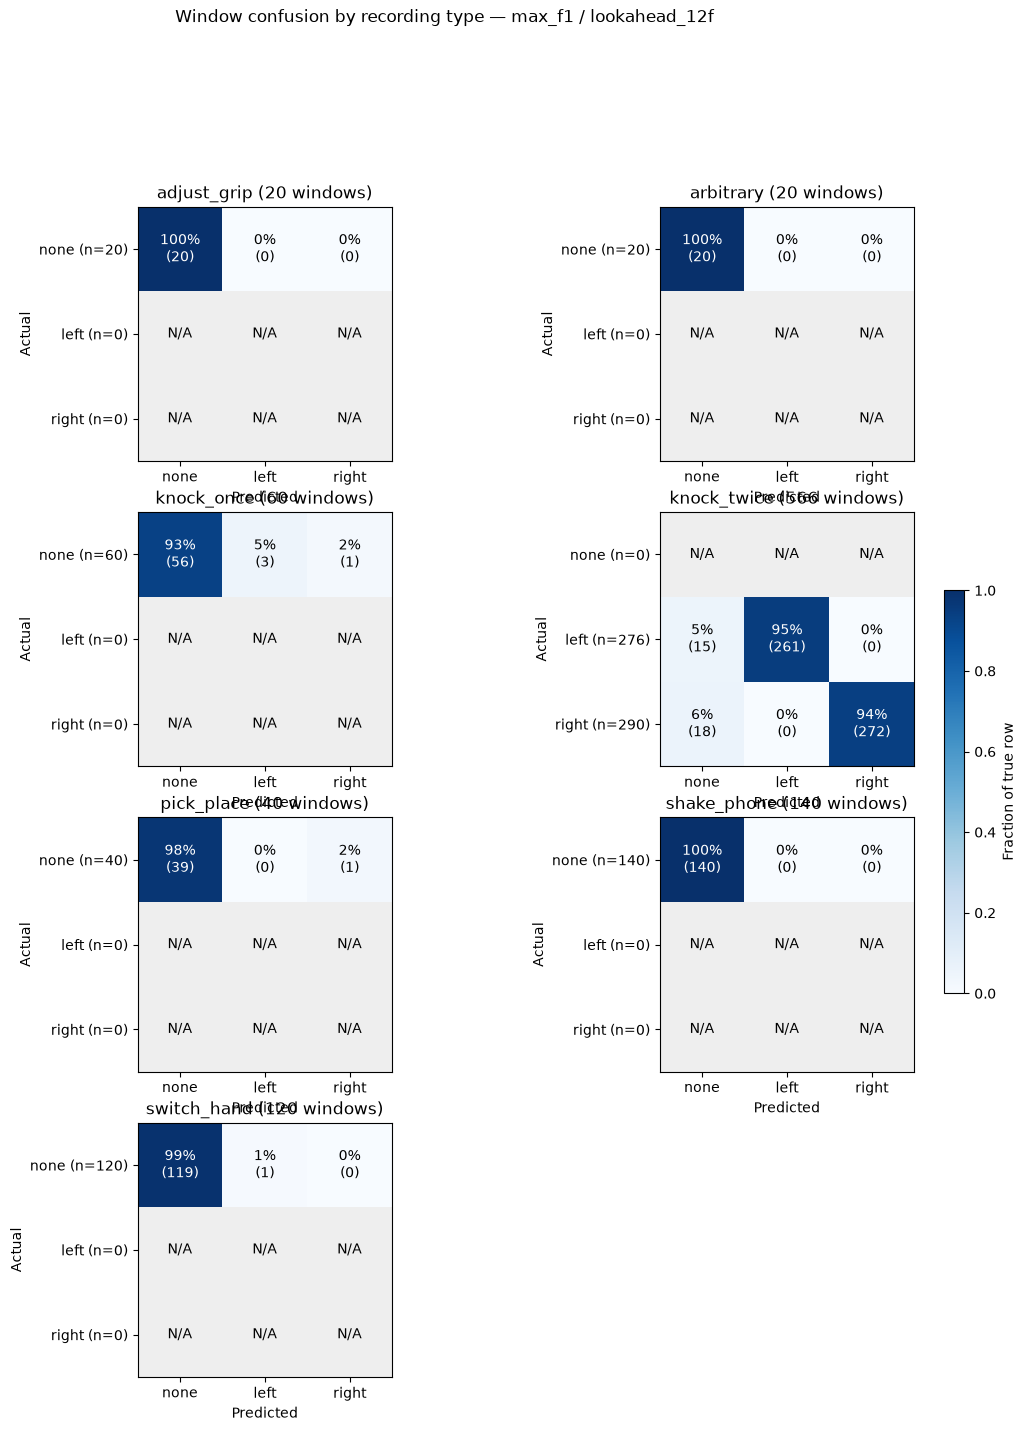

In [70]:
import math
types = sorted(type_metrics.recording_type)
ncols = 2
fig, axes = plt.subplots(math.ceil(len(types) / ncols), ncols,
                         figsize=(13, 3.8 * math.ceil(len(types) / ncols)), squeeze=False)
for ax, recording_type in zip(axes.flat, types):
    group = type_confusion[type_confusion.recording_type == recording_type]
    counts = group['count'].to_numpy().reshape(3, 3)
    totals = counts.sum(axis=1)
    rates = np.divide(counts, totals[:, None], out=np.full((3, 3), np.nan),
                      where=totals[:, None] > 0)
    colors = plt.get_cmap('Blues').copy()
    colors.set_bad('#eeeeee')
    image = ax.imshow(np.ma.masked_invalid(rates), vmin=0, vmax=1, cmap=colors)
    ax.set(title=f'{recording_type} ({int(counts.sum())} windows)',
           xlabel='Predicted', ylabel='Actual', xticks=range(3), yticks=range(3),
           xticklabels=('none', 'left', 'right'),
           yticklabels=[f'{label} (n={n})' for label, n in zip(('none','left','right'), totals)])
    for i in range(3):
        for j in range(3):
            text = f'{rates[i, j]:.0%}\n({counts[i, j]})' if totals[i] else 'N/A'
            ax.text(j, i, text, ha='center', va='center',
                    color='white' if totals[i] and rates[i, j] > .55 else 'black')
for ax in list(axes.flat)[len(types):]:
    ax.axis('off')
fig.colorbar(image, ax=list(axes.flat), fraction=.02, pad=.03, label='Fraction of true row')
fig.suptitle(f'Window confusion by recording type — {TYPE_SELECTION_MODE} / {TYPE_POLICY}', y=1.01)
plt.show()

In [71]:
type_confusion[['recording_type', 'true_class', 'predicted_class', 'count', 'true_count', 'row_fraction']]  # Full table: type_confusion.

,recording_type,true_class,predicted_class,count,true_count,row_fraction
0,adjust_grip,none,none,20,20,1.0
1,adjust_grip,none,left,0,20,0.0
2,adjust_grip,none,right,0,20,0.0
3,adjust_grip,left,none,0,0,NaN
4,adjust_grip,left,left,0,0,NaN
...,...,...,...,...,...,...
58,switch_hand,left,left,0,0,NaN
59,switch_hand,left,right,0,0,NaN
60,switch_hand,right,none,0,0,NaN
61,switch_hand,right,left,0,0,NaN


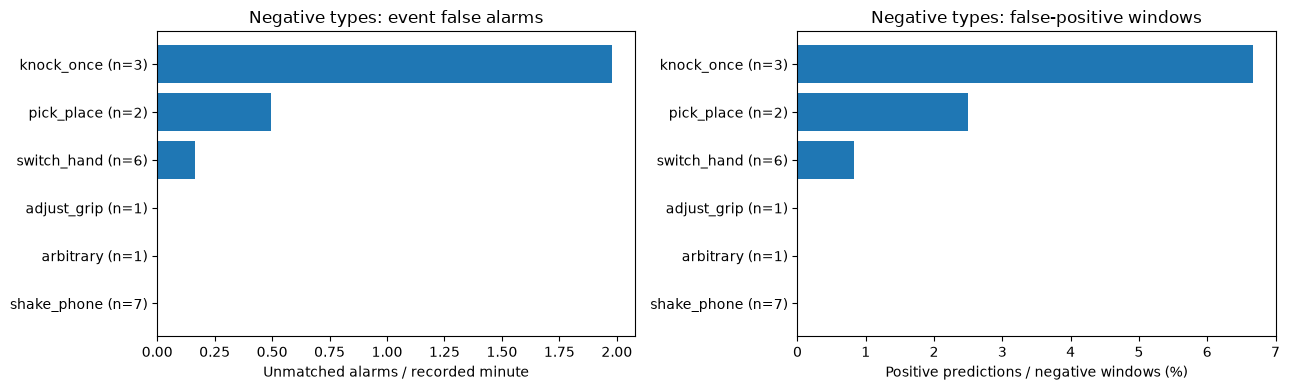

In [72]:
negative_types = type_metrics[type_metrics.n_true_events == 0].sort_values('event_fp_per_min', ascending=False)
if len(negative_types):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    labels = [f'{row.recording_type} (n={row.recordings})' for row in negative_types.itertuples()]
    axes[0].barh(labels, negative_types.event_fp_per_min)
    axes[0].set(xlabel='Unmatched alarms / recorded minute', title='Negative types: event false alarms')
    axes[1].barh(labels, 100 * negative_types.window_false_positive_rate)
    axes[1].set(xlabel='Positive predictions / negative windows (%)',
                title='Negative types: false-positive windows')
    for ax in axes: ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [73]:
type_metrics  # Filter recording_type and compare window errors with event false alarms/minute.

,selection_mode,policy,left_threshold,right_threshold,recording_type,recordings,minutes,n_windows,n_true_events,n_windows_none,...,evaluation_split,evaluation_design,threshold_grid,recall_target,fp_per_min_limit,timely_budget_frames,early_allowance_frames,max_late_frames,refractory_sec,frame_label_half_width
0,max_f1,lookahead_12f,0.55,0.55,adjust_grip,1,1.010167,20,0,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
1,max_f1,lookahead_12f,0.55,0.55,arbitrary,1,1.010333,20,0,20,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
2,max_f1,lookahead_12f,0.55,0.55,knock_once,3,3.028500,60,0,60,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
3,max_f1,lookahead_12f,0.55,0.55,knock_twice,29,28.576833,566,566,0,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
4,max_f1,lookahead_12f,0.55,0.55,pick_place,2,2.020833,40,0,40,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
5,max_f1,lookahead_12f,0.55,0.55,shake_phone,7,7.068667,140,0,140,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10
6,max_f1,lookahead_12f,0.55,0.55,switch_hand,6,6.059000,120,0,120,...,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,1.0,10,20,30,0.5,10


### Per-recording and per-type exports for every feasible selection mode
The plots above use the chosen `TYPE_SELECTION_MODE` and `TYPE_POLICY`. For cross-model comparisons, the following tables additionally score each *feasible* selected pair, so the comparison notebook can switch modes without silently reusing the wrong type statistics. No threshold grid is rerun here.

In [74]:
other_recordings = []
for selected in selected_thresholds[selected_thresholds.feasible].itertuples(index=False):
    if selected.selection_mode == TYPE_SELECTION_MODE and selected.policy == TYPE_POLICY:
        continue  # Reuse the detailed recording_metrics computed above.
    tl, tr = float(selected.left_threshold), float(selected.right_threshold)
    predicted_windows = choose_classes(window_side_scores, tl, tr)
    for rec in recordings:
        file = rec.path.name
        positions = np.flatnonzero(windows.file.to_numpy() == file)
        cm = np.zeros((3, 3), dtype=int)
        np.add.at(cm, (window_truth[positions], predicted_windows[positions]), 1)
        alarms_for_file = emit_alarms_pair(probabilities[file], tl, tr, POLICIES[selected.policy],
                                          round(.5 * rec.fs))
        matches = match_alarms(rec.events, alarms_for_file)
        side_counts = {}
        for cls, label in ((1, 'left'), (2, 'right')):
            tp = sum(rec.events[i][1] == cls for i, _ in matches)
            side_counts.update({f'event_{label}_tp': tp,
                                f'event_{label}_fp': sum(a['class_id'] == cls for a in alarms_for_file) - tp,
                                f'event_{label}_fn': sum(c == cls for _, c in rec.events) - tp})
        other_recordings.append(dict(selection_mode=selected.selection_mode, policy=selected.policy,
                                     left_threshold=tl, right_threshold=tr, file=file, user=rec.user,
                                     recording_type=type_from_filename(file), minutes=len(rec.imu)/rec.fs/60,
                                     n_windows=len(positions), n_true_events=len(rec.events),
                                     window_tp=int(cm[1:, 1:].sum()), window_fp=int(cm[0, 1:].sum()),
                                     window_fn=int(cm[1:, 0].sum()), window_tn=int(cm[0, 0]),
                                     event_tp=len(matches), event_fp=len(alarms_for_file)-len(matches),
                                     event_fn=len(rec.events)-len(matches), **side_counts,
                                     **{f'cm_{i}{j}': int(cm[i, j]) for i in range(3) for j in range(3)}))
recording_metrics_all_modes = pd.concat(
    [recording_metrics, pd.DataFrame(other_recordings)], ignore_index=True).assign(**comparison_metadata)
recording_metrics_all_modes['event_fp_per_min'] = (recording_metrics_all_modes.event_fp /
                                                    recording_metrics_all_modes.minutes)
recording_metrics_all_modes['window_accuracy'] = (
    sum(recording_metrics_all_modes[f'cm_{i}{i}'] for i in range(3)) /
    recording_metrics_all_modes.n_windows)
assert len(recording_metrics_all_modes) == len(recordings) * int(selected_thresholds.feasible.sum())
recording_metrics_all_modes[['selection_mode', 'policy', 'recording_type', 'file',
                             'event_tp', 'event_fp', 'event_fn', 'window_fp', 'window_fn']]

,selection_mode,policy,recording_type,file,event_tp,event_fp,event_fn,window_fp,window_fn
0,max_f1,lookahead_12f,knock_twice,imuStrict_Miguel_knock_twice_left_20260929_115...,20,0,0,0,0
1,max_f1,lookahead_12f,knock_twice,imuStrict_Miguel_knock_twice_left_20260929_153...,19,0,1,0,1
2,max_f1,lookahead_12f,knock_twice,imuStrict_Miguel_knock_twice_left_20260929_153...,20,0,0,0,0
3,max_f1,lookahead_12f,knock_twice,imuStrict_Miguel_knock_twice_left_20260930_150...,19,3,1,0,1
4,max_f1,lookahead_12f,knock_twice,imuStrict_Miguel_knock_twice_left_20260930_150...,18,0,2,0,2
...,...,...,...,...,...,...,...,...,...
240,timely_recall_fp_budget,lookahead_12f,pick_place,imu_ZR_pick_place_20260909_091335.csv,0,1,0,1,0
241,timely_recall_fp_budget,lookahead_12f,shake_phone,imu_ZR_shake_phone_20260904_102826.csv,0,0,0,0,0
242,timely_recall_fp_budget,lookahead_12f,shake_phone,imu_ZR_shake_phone_20260908_175719.csv,0,0,0,0,0
243,timely_recall_fp_budget,lookahead_12f,shake_phone,imu_ZR_shake_phone_20260909_091204.csv,0,0,0,0,0


In [75]:
all_type_rows = []
for (mode, policy, tl, tr, recording_type), group in recording_metrics_all_modes.groupby(
        ['selection_mode', 'policy', 'left_threshold', 'right_threshold', 'recording_type'], sort=True):
    cm = np.array([[int(group[f'cm_{i}{j}'].sum()) for j in range(3)] for i in range(3)])
    wtp, wfp, wfn, wtn = (int(group[f'window_{name}'].sum()) for name in ('tp', 'fp', 'fn', 'tn'))
    etp, efp, efn = (int(group[f'event_{name}'].sum()) for name in ('tp', 'fp', 'fn'))
    minutes = group.minutes.sum()
    row = dict(selection_mode=mode, policy=policy, left_threshold=tl, right_threshold=tr,
               recording_type=recording_type, recordings=len(group), minutes=minutes,
               n_windows=int(cm.sum()), n_true_events=int(group.n_true_events.sum()),
               window_tp=wtp, window_fp=wfp, window_fn=wfn, window_tn=wtn,
               window_accuracy=divide(np.trace(cm), cm.sum()),
               window_precision=divide(wtp, wtp+wfp), window_recall=divide(wtp, wtp+wfn),
               window_f1=divide(2*wtp, 2*wtp+wfp+wfn),
               window_false_positive_rate=divide(wfp, wfp+wtn),
               event_tp=etp, event_fp=efp, event_fn=efn,
               event_precision=divide(etp, etp+efp), event_recall=divide(etp, etp+efn),
               event_f1=divide(2*etp, 2*etp+efp+efn), event_fp_per_min=divide(efp, minutes),
               **{f'cm_{i}{j}': int(cm[i, j]) for i in range(3) for j in range(3)})
    for side in ('left', 'right'):
        tp, fp, fn = (int(group[f'event_{side}_{name}'].sum()) for name in ('tp', 'fp', 'fn'))
        row.update({f'event_{side}_tp': tp, f'event_{side}_fp': fp,
                    f'event_{side}_fn': fn, f'event_{side}_recall': divide(tp, tp+fn),
                    f'event_{side}_precision': divide(tp, tp+fp),
                    f'event_{side}_f1': divide(2*tp, 2*tp+fp+fn)})
    all_type_rows.append(row)
type_metrics_all_modes = pd.DataFrame(all_type_rows).assign(**comparison_metadata)
for selected in selected_thresholds[selected_thresholds.feasible].itertuples(index=False):
    files = recording_metrics_all_modes[(recording_metrics_all_modes.selection_mode == selected.selection_mode) &
                                       (recording_metrics_all_modes.policy == selected.policy)]
    by_type = type_metrics_all_modes[(type_metrics_all_modes.selection_mode == selected.selection_mode) &
                                     (type_metrics_all_modes.policy == selected.policy)]
    overall = comparison_summary[(comparison_summary.selection_mode == selected.selection_mode) &
                                 (comparison_summary.policy == selected.policy) &
                                 (comparison_summary.side == 'all')]
    for prefix, level in (('window', 'window'), ('event', 'event')):
        expected = overall[overall.level == level].iloc[0]
        for name in ('tp', 'fp', 'fn'):
            assert files[f'{prefix}_{name}'].sum() == by_type[f'{prefix}_{name}'].sum() == expected[name]
type_metrics_all_modes[['selection_mode', 'policy', 'left_threshold', 'right_threshold',
                        'recording_type', 'recordings', 'event_tp', 'event_fp', 'event_fn',
                        'event_fp_per_min', 'window_false_positive_rate']]

,selection_mode,policy,left_threshold,right_threshold,recording_type,recordings,event_tp,event_fp,event_fn,event_fp_per_min,window_false_positive_rate
0,fp_budget_max_recall,lookahead_12f,0.55,0.40,adjust_grip,1,0,0,0,0.000000,0.000000
1,fp_budget_max_recall,lookahead_12f,0.55,0.40,arbitrary,1,0,0,0,0.000000,0.000000
2,fp_budget_max_recall,lookahead_12f,0.55,0.40,knock_once,3,0,11,0,3.632161,0.133333
3,fp_budget_max_recall,lookahead_12f,0.55,0.40,knock_twice,29,528,31,38,1.084795,NaN
4,fp_budget_max_recall,lookahead_12f,0.55,0.40,pick_place,2,0,1,0,0.494845,0.025000
5,fp_budget_max_recall,lookahead_12f,0.55,0.40,shake_phone,7,0,0,0,0.000000,0.000000
6,fp_budget_max_recall,lookahead_12f,0.55,0.40,switch_hand,6,0,2,0,0.330087,0.016667
7,max_f1,lookahead_12f,0.55,0.55,adjust_grip,1,0,0,0,0.000000,0.000000
8,max_f1,lookahead_12f,0.55,0.55,arbitrary,1,0,0,0,0.000000,0.000000
9,max_f1,lookahead_12f,0.55,0.55,knock_once,3,0,6,0,1.981179,0.066667


### Optional CSV export
Set `SAVE_COMPARISON=True` to save the selected pairs, comparison, full sweep, and per-file/type tables (including all feasible modes). With an evaluation-data override, the default export directory is separate from the checkpoint so historical exports are preserved. Existing filenames in the chosen export folder will be overwritten if you rerun this cell.

In [76]:
SAVE_COMPARISON = True
if SAVE_COMPARISON:
    export_dir = EVALUATION_OUTPUT_DIR / 'threshold_comparison'
    export_dir.mkdir(parents=True, exist_ok=True)
    for name, table in [('selected_thresholds', selected_thresholds),
                        ('comparison_summary', comparison_summary),
                        ('comparison_metrics', comparison_metrics),
                        ('pair_sweep', pair_sweep),
                        (f'recording_metrics_{TYPE_SELECTION_MODE}_{TYPE_POLICY}', recording_metrics),
                        (f'type_metrics_{TYPE_SELECTION_MODE}_{TYPE_POLICY}', type_metrics),
                        (f'type_confusion_{TYPE_SELECTION_MODE}_{TYPE_POLICY}', type_confusion),
                        ('recording_metrics_all_modes', recording_metrics_all_modes),
                        ('type_metrics_all_modes', type_metrics_all_modes)]:
        exported = table.assign(**comparison_metadata) if name in ('selected_thresholds', 'pair_sweep') else table
        exported.to_csv(export_dir / f'{name}.csv', index=False)
    (export_dir / 'evaluation_context.json').write_text(
        json.dumps(evaluation_context, indent=2, sort_keys=True) + '\n')
    print(f'Saved comparison tables to {export_dir}')
else:
    print('Set SAVE_COMPARISON = True to export the comparison and per-type CSV tables.')

Saved comparison tables to /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/TapRecognition/testing_checkpoints/evaluation_exports/lstm64d10(102)_on_data_05_10_26/threshold_comparison


In [77]:
comparison_metrics

,model_id,checkpoint_sha256,checkpoint_epoch,validation_sha256,preprocessing_sha256,selection_split,evaluation_split,evaluation_design,threshold_grid,recall_target,...,frame_label_half_width,selection_mode,policy,left_threshold,right_threshold,feasible,level,side,metric,value
0,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,window,all,checkpoint_training_seed,102.000000
1,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,window,left,checkpoint_training_seed,102.000000
2,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,window,right,checkpoint_training_seed,102.000000
3,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,frame,all,checkpoint_training_seed,102.000000
4,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,max_f1,lookahead_12f,0.55,0.55,True,frame,left,checkpoint_training_seed,102.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,recall_target_min_fp,lookahead_12f,0.70,0.60,True,event,right,timely_recall,0.082759
866,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,fp_budget_max_recall,lookahead_12f,0.55,0.40,True,event,left,timely_recall,0.065217
867,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,fp_budget_max_recall,lookahead_12f,0.55,0.40,True,event,right,timely_recall,0.168966
868,lstm64d10(102),8461837a6b85dfa53b0ae90e17ab3c813ddc78618ea357...,16,0d39cc331e0ebef0ab09b4825be76b4f7c29a1d71bc49a...,92e101fc11aa3546cc138c2c7c433a7b792409255328e2...,valid,valid,tuned_validation,"0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8",0.9,...,10,timely_recall_fp_budget,lookahead_12f,0.70,0.35,True,event,left,timely_recall,0.036232
